In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np

for _path in (Path.cwd(), *Path.cwd().parents):
    if (_path / "pyproject.toml").is_file():
        _root = str(_path)
        if _root not in sys.path:
            sys.path.insert(0, _root)
        break
else:
    raise RuntimeError("Could not find project root (pyproject.toml)")

import matplotlib.pyplot as plt

from cycles.gaussian_fit_cycle_analysis import (
    build_cell_receptive_fields_df,
    compute_aic_r2_correlation,
    outlier_points_summary_df,
    select_aic_r2_outlier_points,
)
from cycles.gaussian_fit_cycle_plots import (
    plot_aic_r2_correlation,
    plot_all_outlier_analysis,
    plot_nan_r2_gaussian_evolutions,
    save_figure,
)
from cycles.cycles_paths import (
    GAUSSIAN_EVOLUTION_PLOTS_DIR,
    PLOTS_DIR,
    RESULTS_DIR,
)

In [2]:
GAUSSIANS_RESULTS_PATH = RESULTS_DIR / "gaussian_rf_fits.npz"
RAW_DATA_DIR = RESULTS_DIR
TRUNCATED_FILE_PATHS = [RESULTS_DIR/fn for fn in ["cycles_ratemaps_truncated_10.npz","cycles_ratemaps_truncated_10_20.npz","cycles_ratemaps_truncated_20_30.npz"]]
assert GAUSSIANS_RESULTS_PATH.is_file(), f"File {GAUSSIANS_RESULTS_PATH.resolve()} does not exist"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
data = np.load(GAUSSIANS_RESULTS_PATH)
print("\n".join([f"{k}: {v.shape}" for k, v in data.items()]))

r2: (600, 1000)
gaussian_params: (600, 1000, 2, 5)
aic: (600, 1000)
signal_mean: (600, 1000)
signal_max: (600, 1000)
signal_std: (600, 1000)
visit_start: ()
visit_end: ()
n_gaussians: ()
param_names: (5,)
source_path: ()
cycle_ids: (600,)
room_ids: (600,)


In [4]:
df_cell_receptive_fields = build_cell_receptive_fields_df(GAUSSIANS_RESULTS_PATH)
df_cell_receptive_fields.head()

cycle_id  room_id        r2           aic  signal_mean  \
visit_idx cell_idx                                                           
0         0                0        5  0.932411 -57070.979869     0.149039   
          1                0        5  0.968122 -64969.625270     0.087362   
          2                0        5       NaN           NaN     0.000000   
          3                0        5  0.980627 -66346.599297     0.116726   
          4                0        5  0.914126 -57329.403547     0.119522   

                    signal_max  signal_std  g1_amplitude    g1_mu_x  \
visit_idx cell_idx                                                    
0         0           1.062096    0.221487      0.919259  27.744782   
          1           1.322703    0.217280      1.231387  40.260280   
          2           0.000000    0.000000           NaN        NaN   
          3           1.300039    0.260175      1.074784  12.728392   
          4           1.126766    0.193974      1.031442  76.587055   

                      g1_mu_y  g1_sigma_x  g1_sigma_y  g2_amplitude  \
visit_idx cell_idx                                                    
0         0         36.355828   14.428128   17.813317      0.062495   
          1         82.619030   12.854219    8.656424      0.159417   
          2               NaN         NaN         NaN           NaN   
          3         35.932685    9.443378   15.926857      0.490339   
          4         35.777506   10.100016   13.393880      0.336487   

                       g2_mu_x     g2_mu_y  g2_sigma_x  g2_sigma_y  
visit_idx cell_idx                                                  
0         0          93.972904  109.000000   27.281327   42.595875  
          1         106.150554   54.308186    9.410953   11.358055  
          2                NaN         NaN         NaN         NaN  
          3          25.366985   23.656318    6.330672   22.848632  
          4          48.224730  102.564052   10.250460   16.767640

In [5]:
THRESHOLD_ACTIVITY_MAX = 0.2

## Cells which at some have a NaN

NaN r2: 321 cells, 20 rooms, 4750 (cell, room) pairs
Plotting 12 of 4750 pairs (cyclical, max_plots=12)


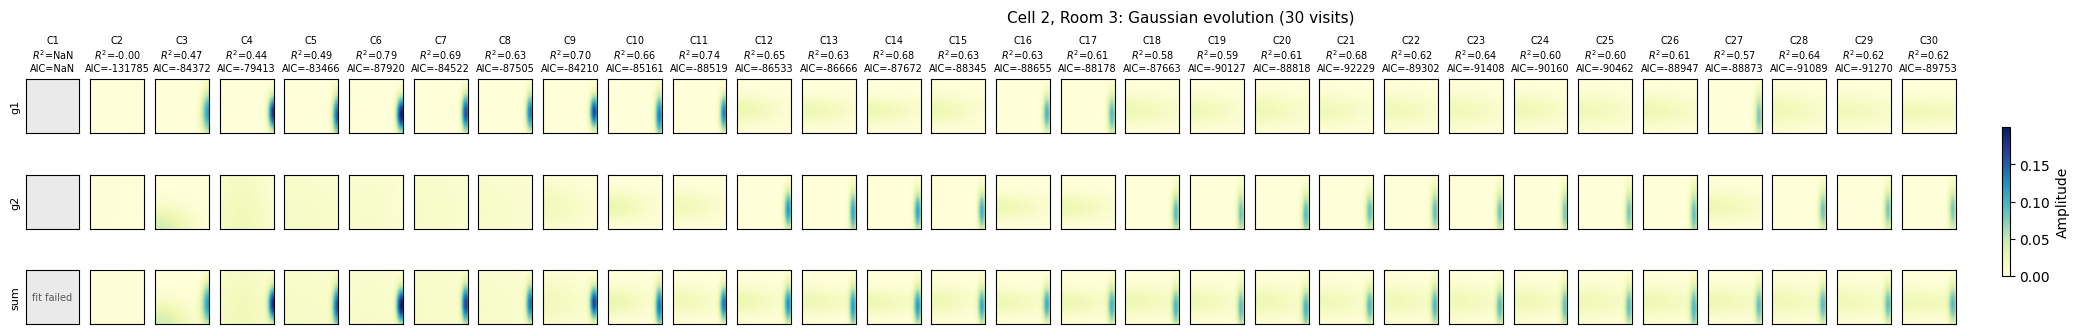

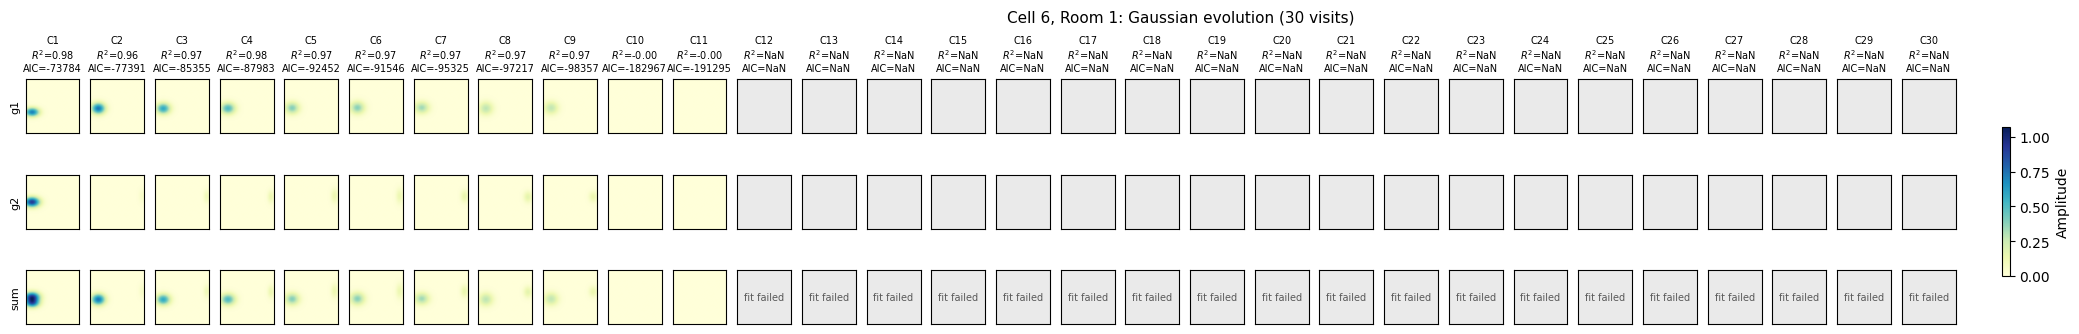

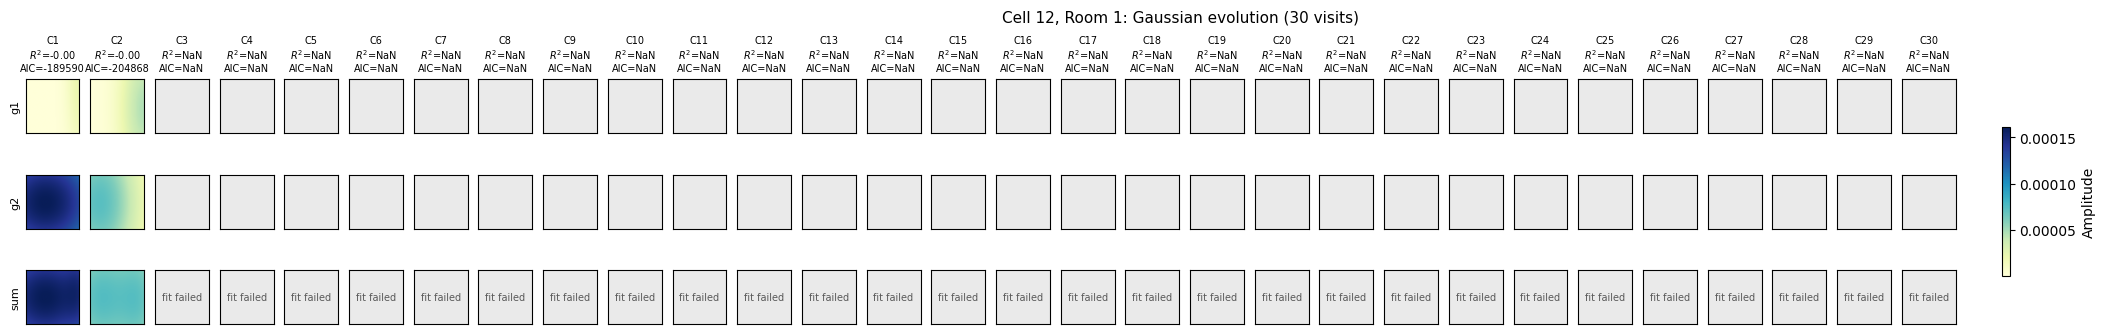

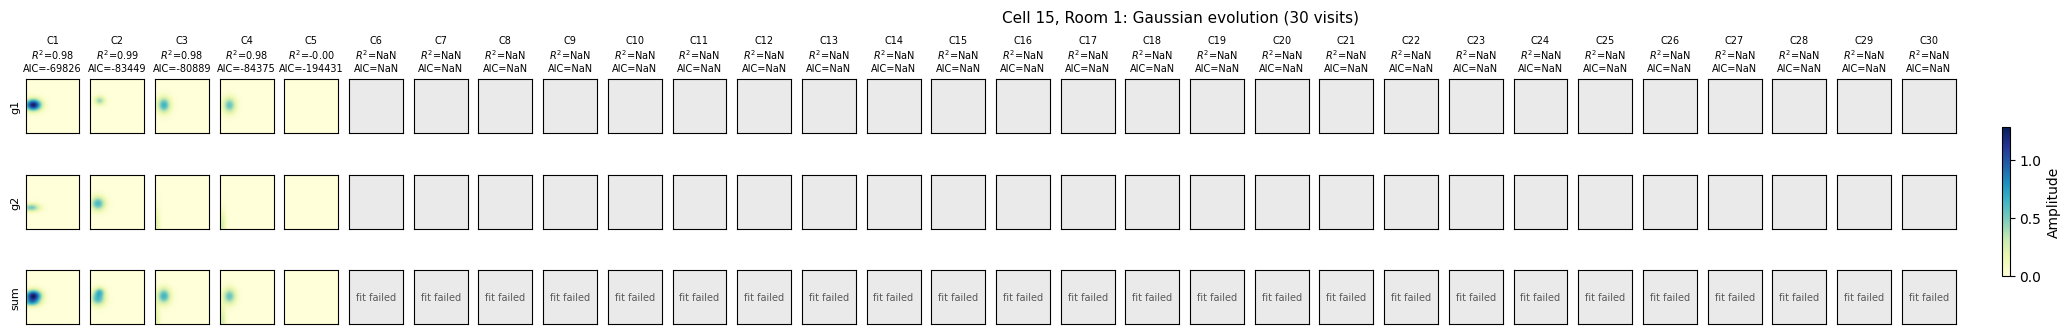

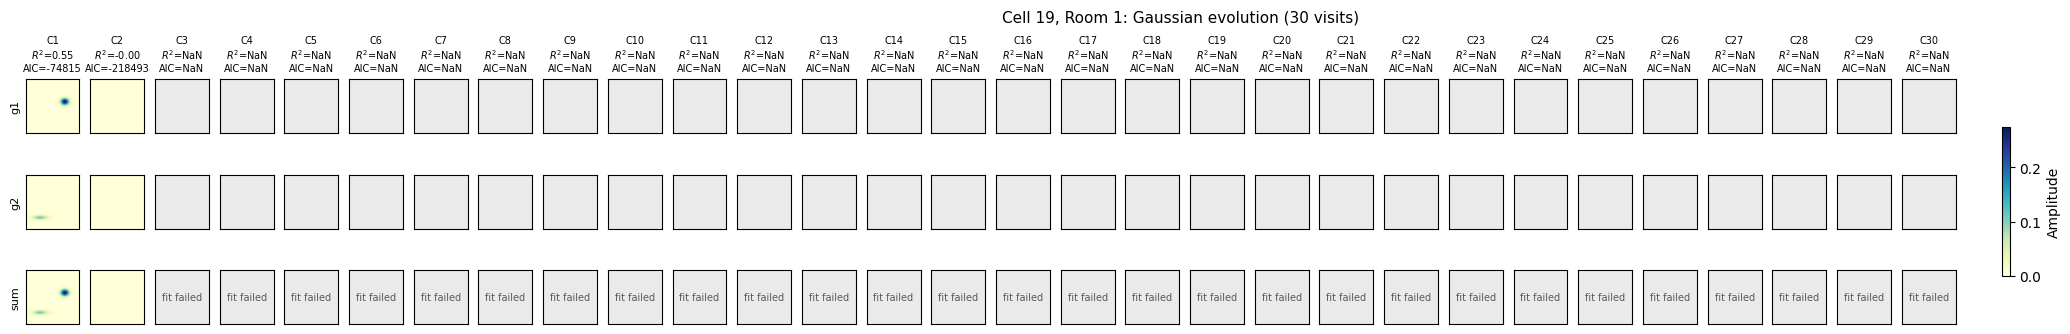

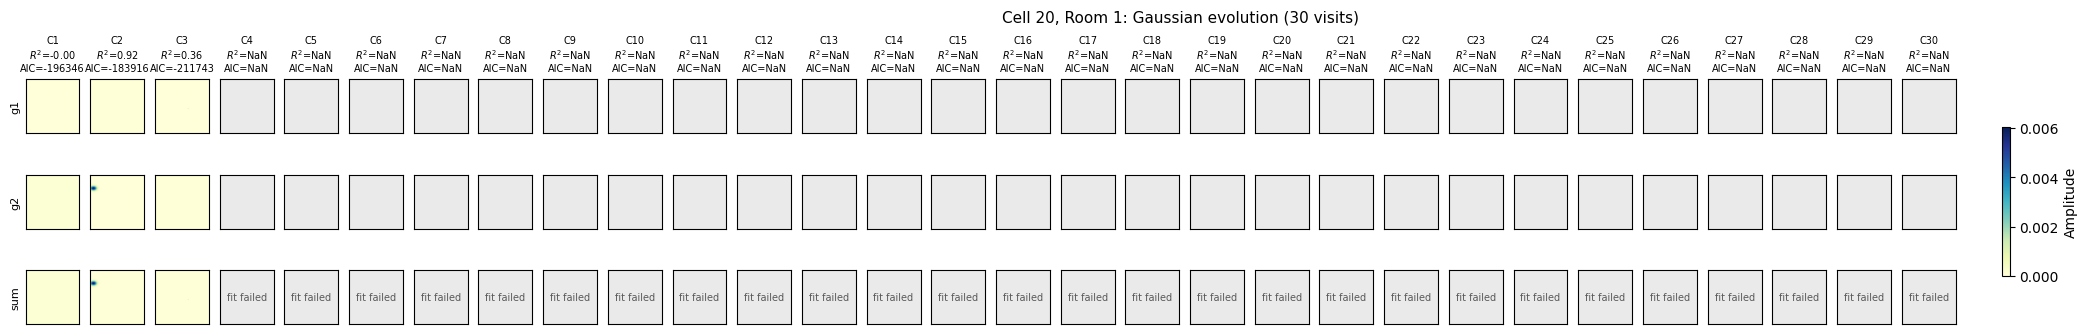

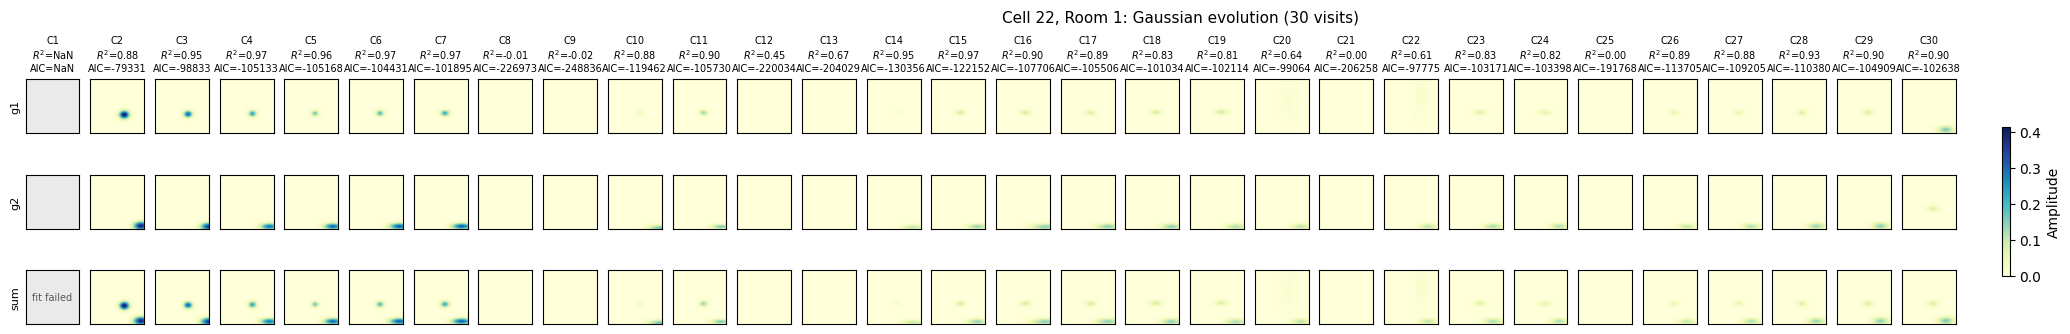

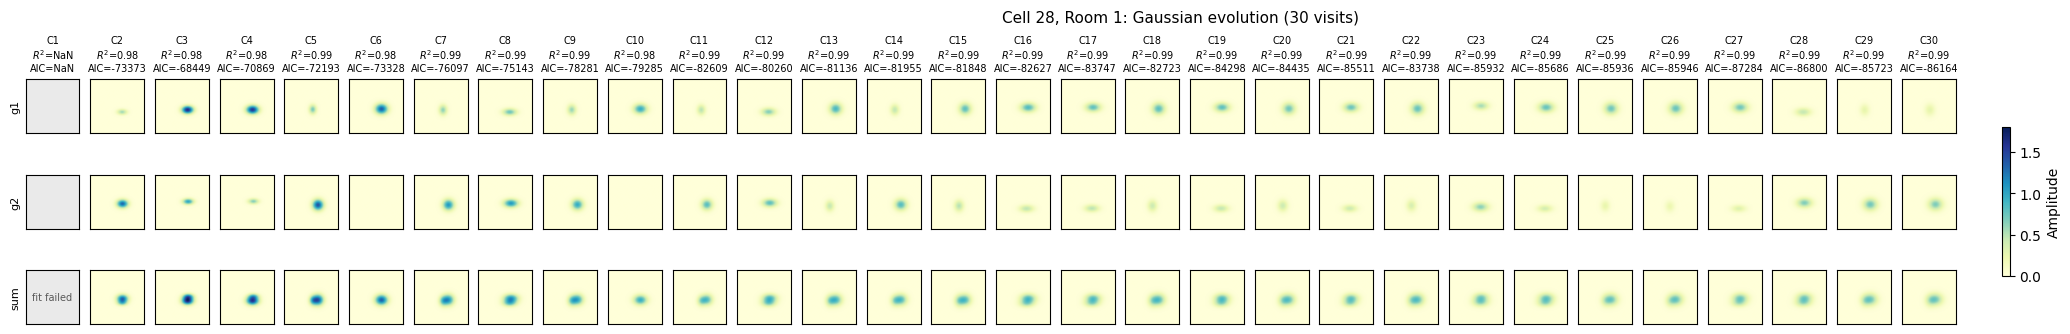

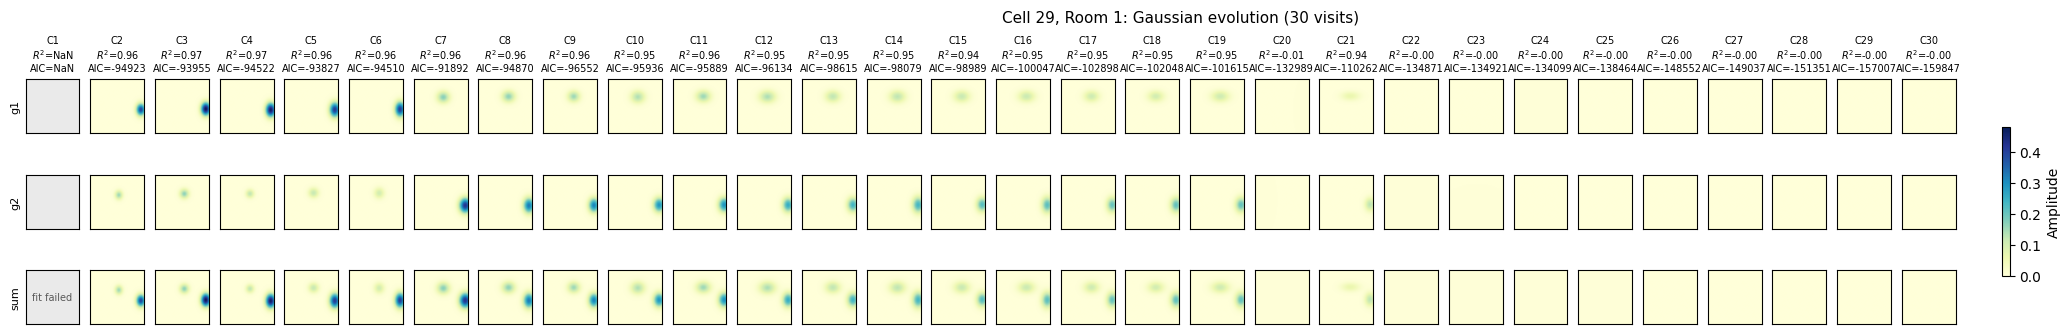

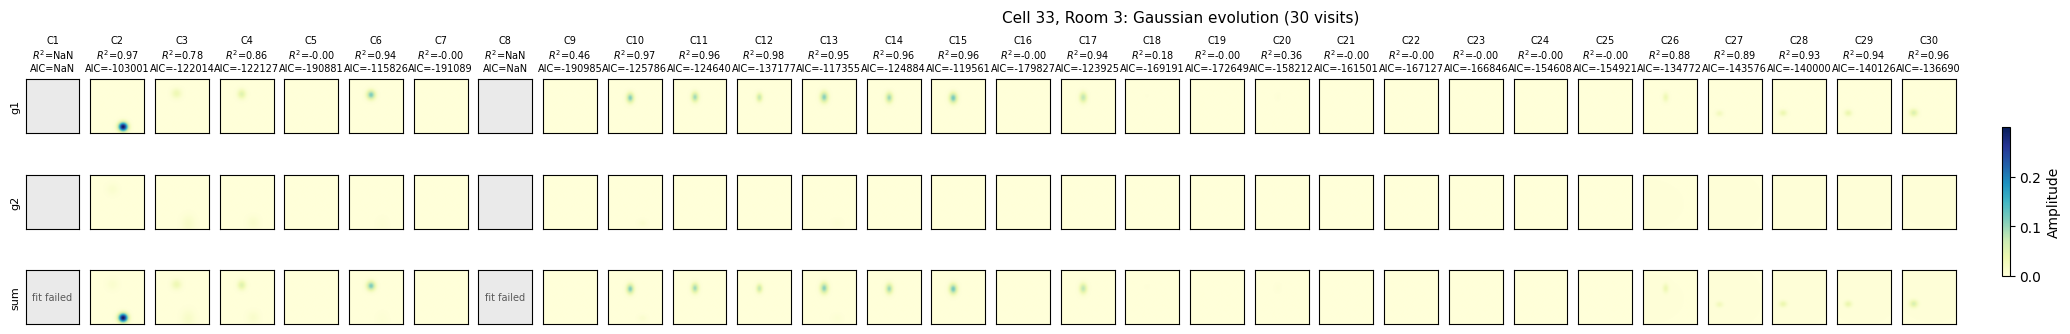

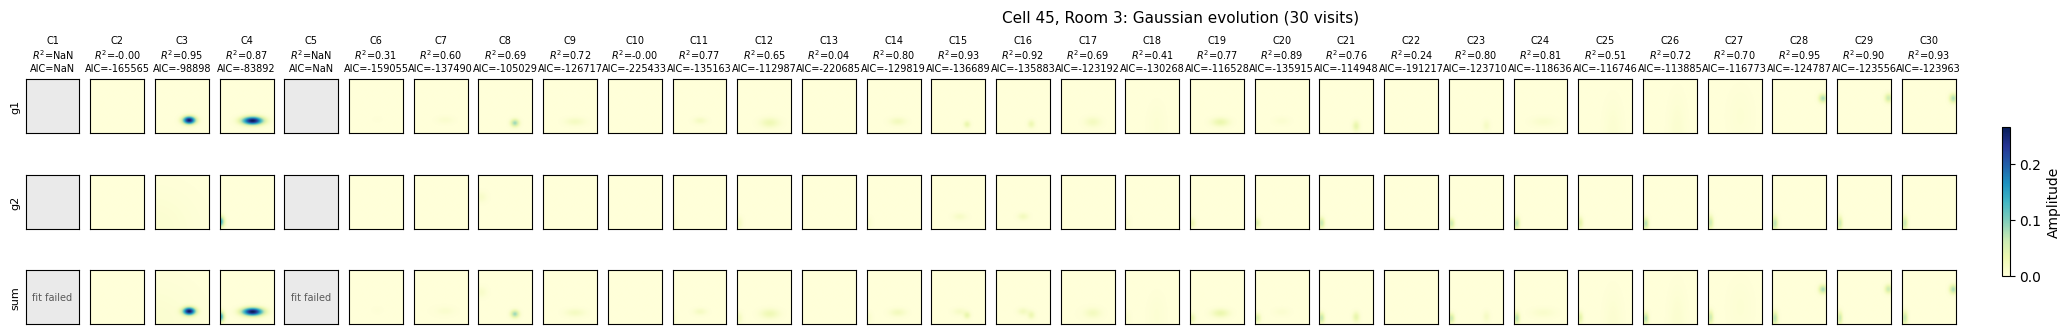

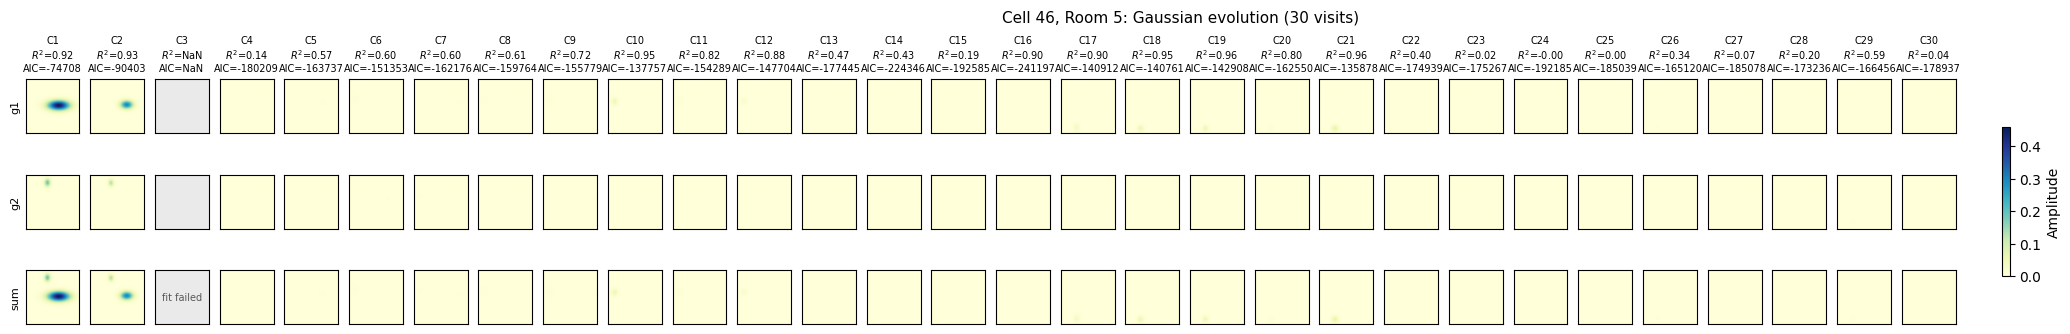

Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/cycles/plots/gaussian_evolution/gaussian_evolution_cell2_room3.pdf
Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/cycles/plots/gaussian_evolution/gaussian_evolution_cell6_room1.pdf
Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/cycles/plots/gaussian_evolution/gaussian_evolution_cell12_room1.pdf
Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/cycles/plots/gaussian_evolution/gaussian_evolution_cell15_room1.pdf
Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/cycles/plots/gaussian_evolution/gaussian_evolution_cell19_room1.pdf
Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/cycles/plots/gaussian_evolution/gaussian_evolution_cell20_room1.pdf
Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/cycles/plots/gaussian_evolution/gaussian_evolution_cell22_room1.pdf
Saved /home/garvalov/thesis/p

In [6]:
MAX_PLOTS = 12  # set None to plot every (cell, room) pair (cyclical order)

figures = plot_nan_r2_gaussian_evolutions(
    df_cell_receptive_fields,
    signal_max_threshold=THRESHOLD_ACTIVITY_MAX,
    max_plots=MAX_PLOTS,
	im_width=1.0
)

GAUSSIAN_EVOLUTION_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

for cell_idx, room_id, fig in figures:
    out_path = (
        GAUSSIAN_EVOLUTION_PLOTS_DIR
        / f"gaussian_evolution_cell{cell_idx}_room{room_id}.pdf"
    )
    save_figure(fig, out_path, close=False)
    plt.show()
    plt.close(fig)
    print(f"Saved {out_path}")

## Correlations

In [7]:
R2_THRESHOLD = 0.5

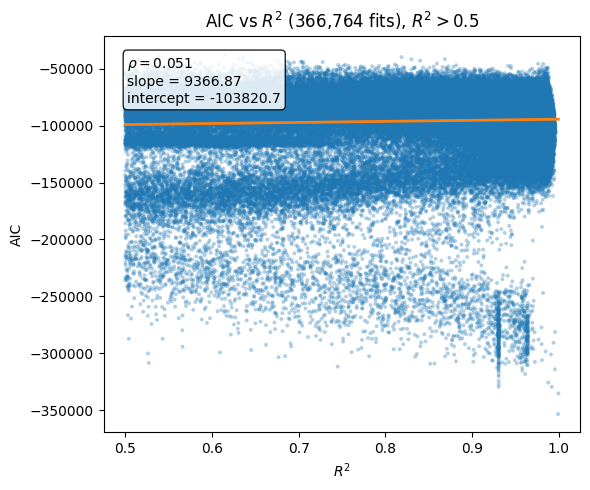

Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/cycles/plots/aic_r2_correlation.pdf (n=366,764, r=0.051)


In [8]:
# AIC R2 correlations
aic_r2_stats = compute_aic_r2_correlation(
    df_cell_receptive_fields,
    r2_threshold=R2_THRESHOLD,
)
df_aic_r2_correlation = aic_r2_stats.filtered_df
fig = plot_aic_r2_correlation(aic_r2_stats, r2_threshold=R2_THRESHOLD)
out_path = PLOTS_DIR / "aic_r2_correlation.pdf"
save_figure(fig, out_path, close=False)
plt.show()
plt.close(fig)
print(
    f"Saved {out_path} "
    f"(n={len(aic_r2_stats.r2):,}, r={aic_r2_stats.correlation:.3f})"
)


### Filter correlations based on mean activity over cycles

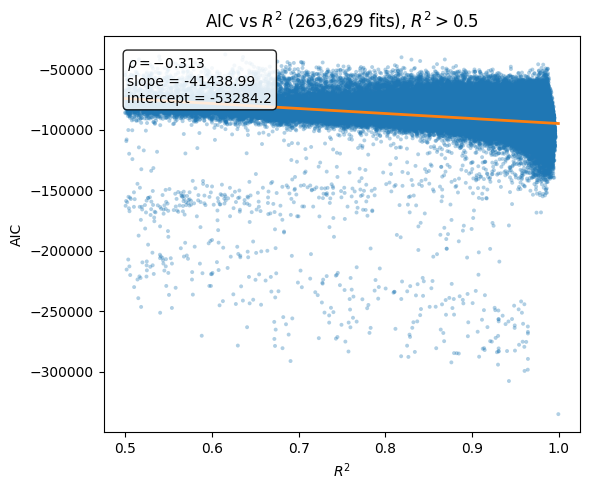

Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/cycles/plots/aic_r2_correlation_filtered.pdf (n=263,629, r=-0.313)


In [9]:

aic_r2_stats_filtered = compute_aic_r2_correlation(
    df_cell_receptive_fields,
    r2_threshold=R2_THRESHOLD,
    signal_max_threshold=THRESHOLD_ACTIVITY_MAX,
)
df_aic_r2_correlation_filtered = aic_r2_stats_filtered.filtered_df
fig = plot_aic_r2_correlation(aic_r2_stats_filtered, r2_threshold=R2_THRESHOLD)
out_path = PLOTS_DIR / "aic_r2_correlation_filtered.pdf"
save_figure(fig, out_path, close=False)
plt.show()
plt.close(fig)
print(
    f"Saved {out_path} "
    f"(n={len(aic_r2_stats_filtered.r2):,}, r={aic_r2_stats_filtered.correlation:.3f})"
)


#### Outliers

In [10]:
initial_raw_gt_data = None

Selected 20 outlier points (target 20; top/bottom 5% $R^2$ pool, AIC extremes)


,r2_band,aic_extremum,visit_idx,cell_idx,room_id,cycle_id,r2,aic
0,top,low,129,247,20,6,0.999377,-335106.540217
1,top,low,570,598,9,28,0.987063,-143189.281971
2,top,low,543,81,14,27,0.987521,-140680.138287
3,top,low,583,430,12,29,0.989756,-140411.771559
4,top,low,491,425,11,24,0.986566,-139572.340467
5,top,high,1,201,20,0,0.987144,-49315.935064
6,top,high,3,253,3,0,0.987156,-49605.462775
7,top,high,8,45,11,0,0.987532,-53242.334737
8,top,high,15,813,18,0,0.986954,-54271.072514
9,top,high,12,469,8,0,0.986560,-54344.666319


/home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/cycles/gaussian_fit_cycle_plots.py:376: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=figsize)


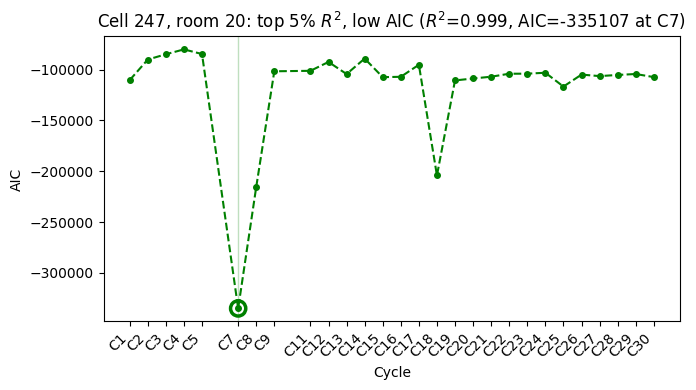

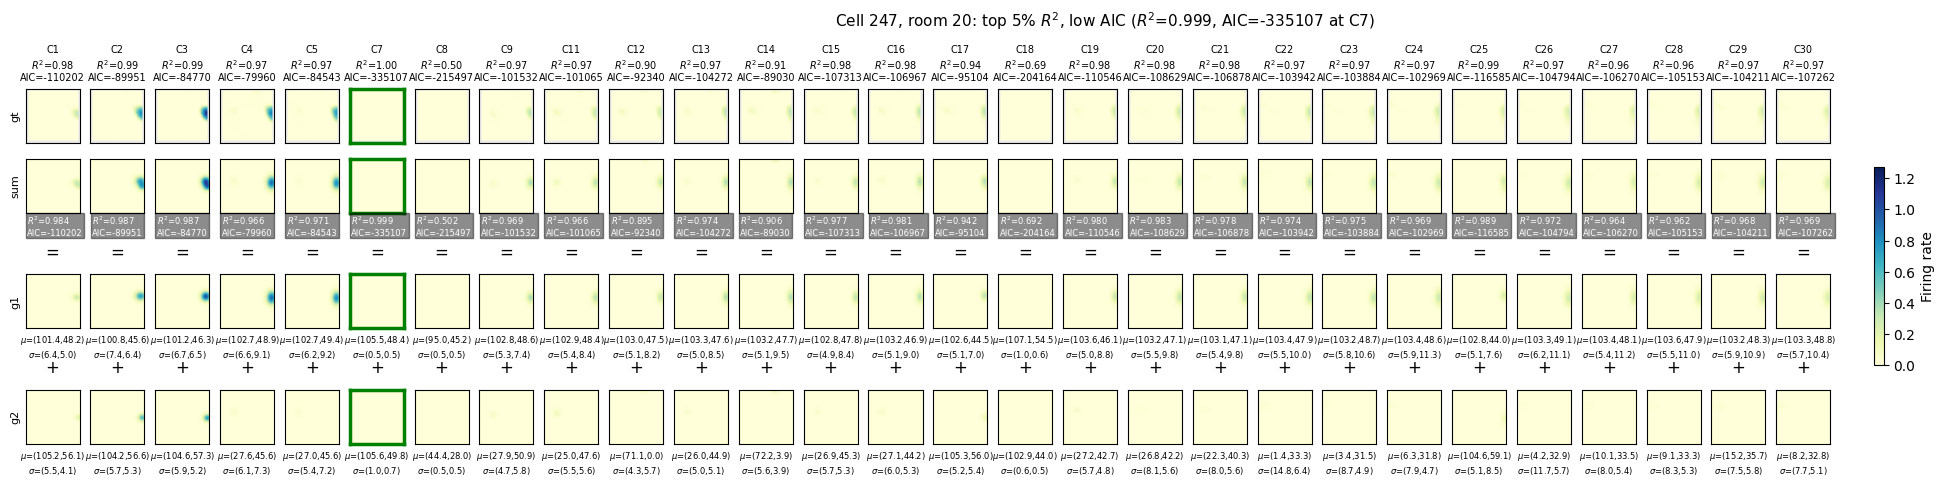

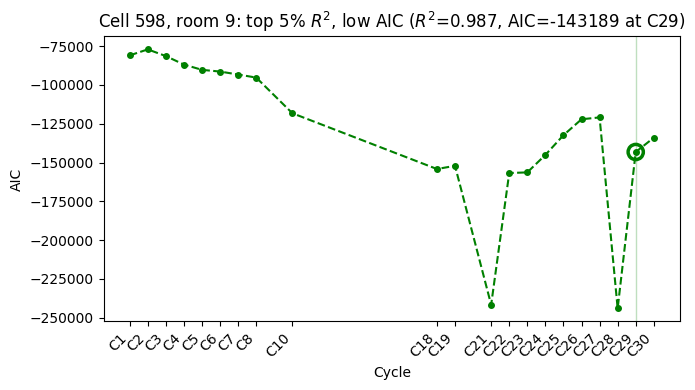

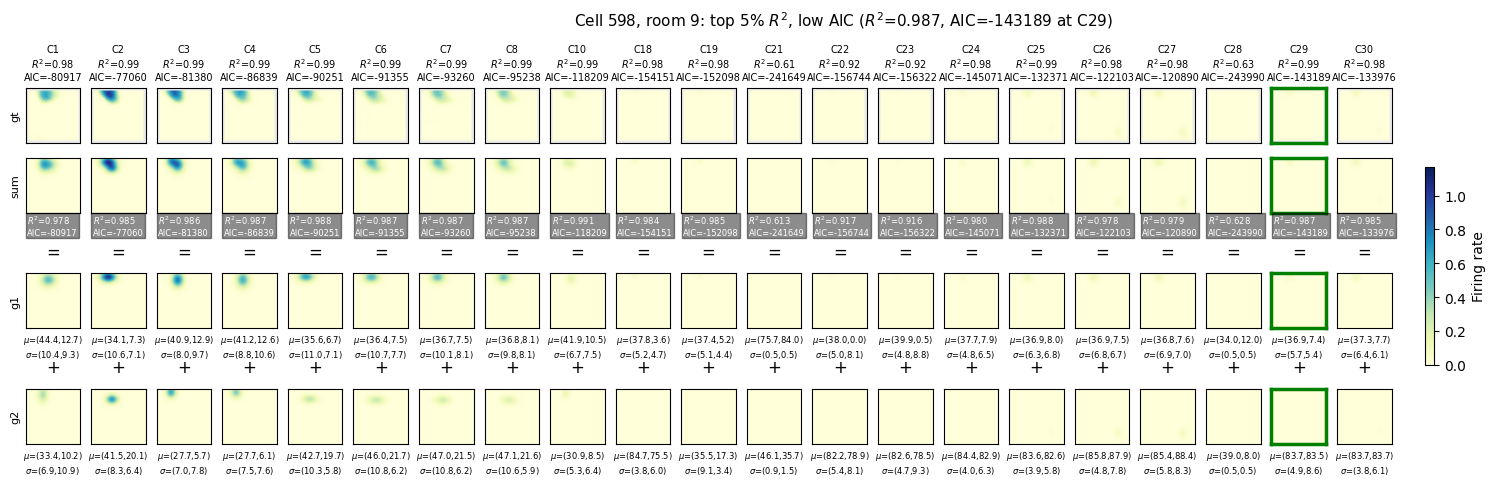

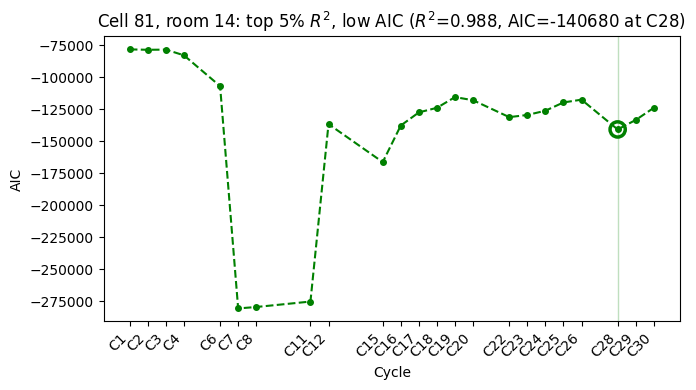

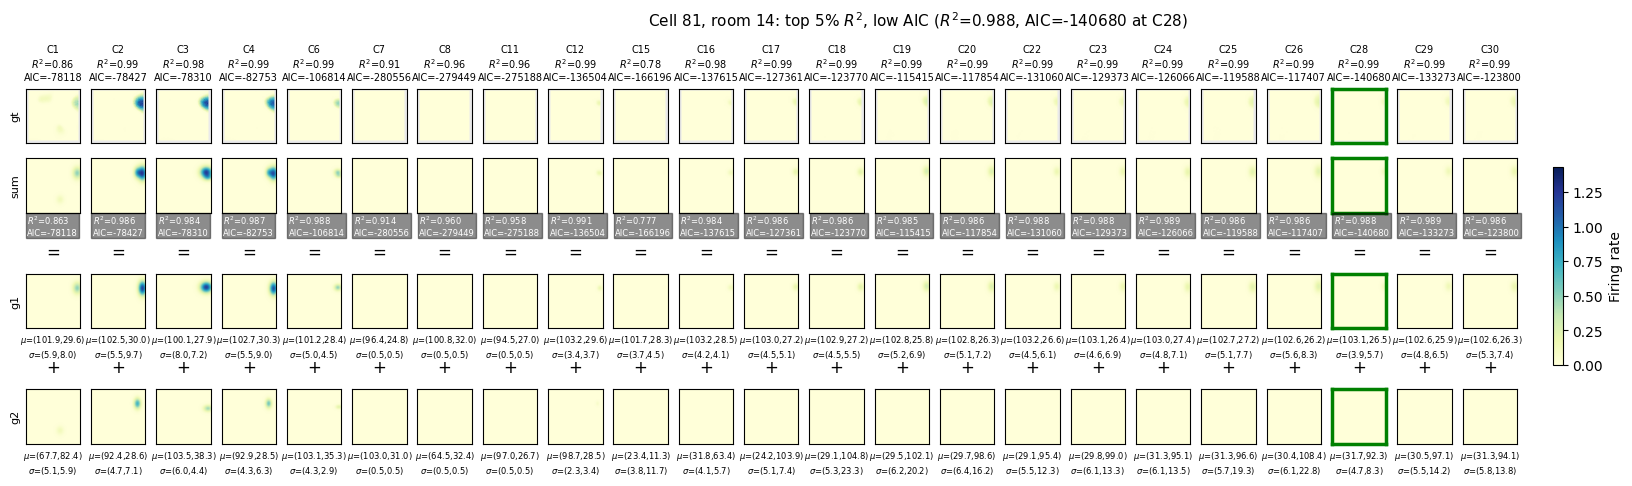

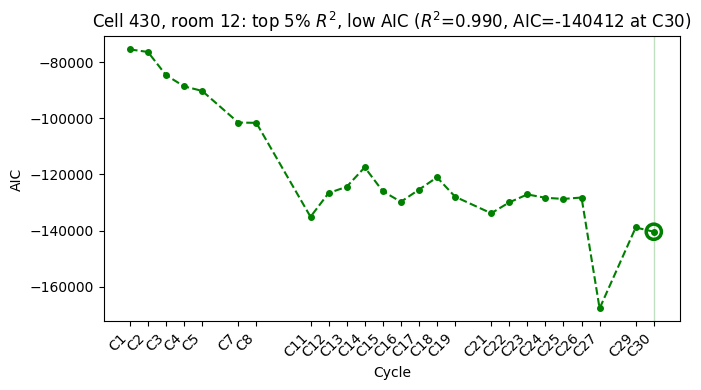

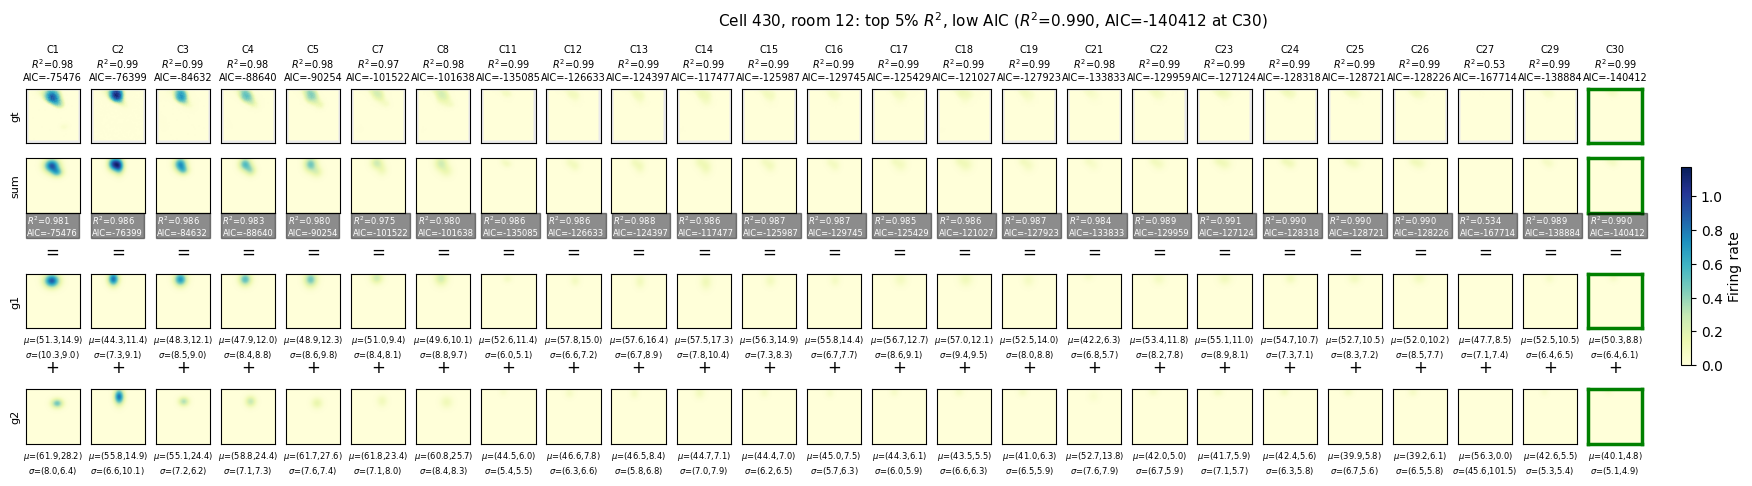

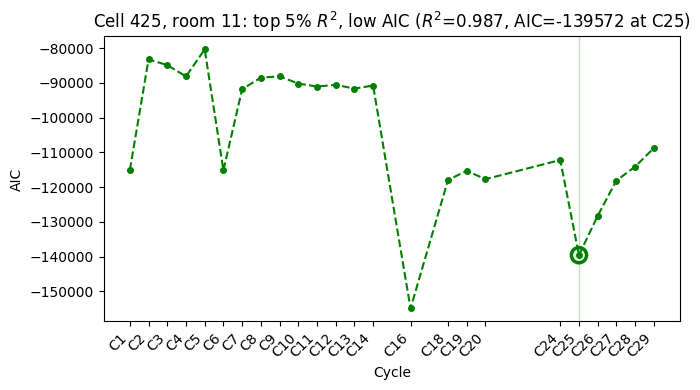

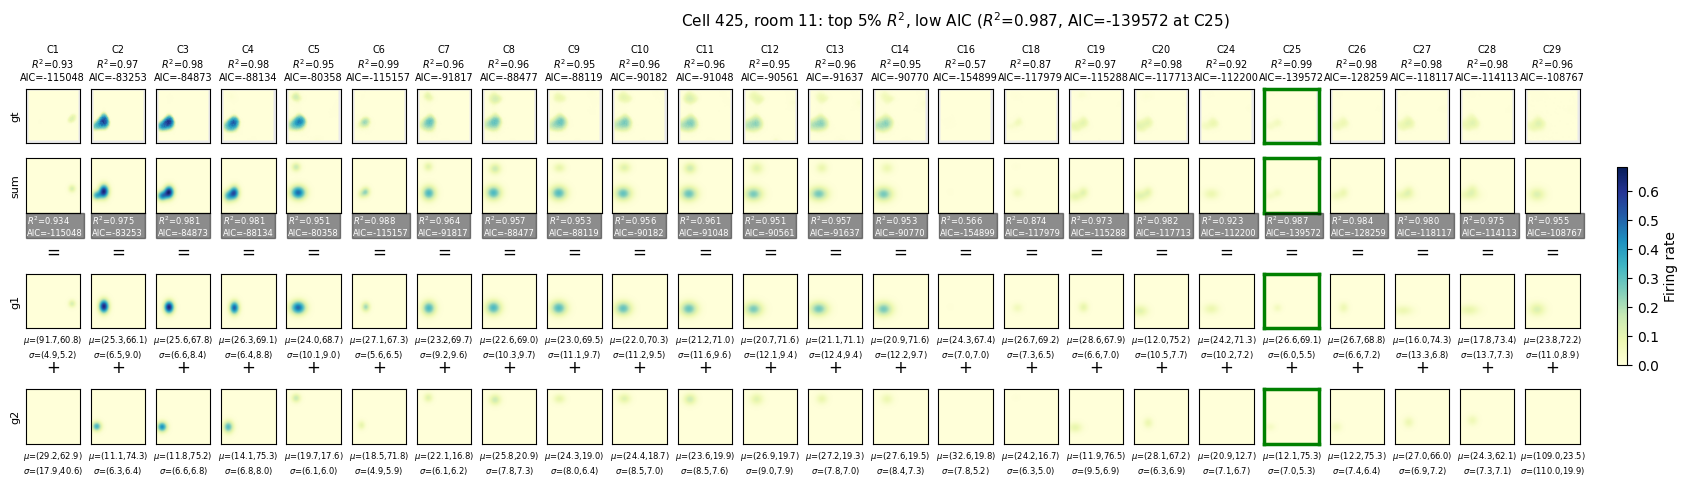

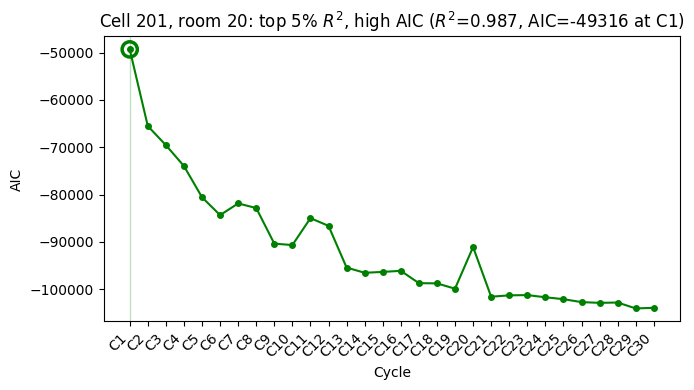

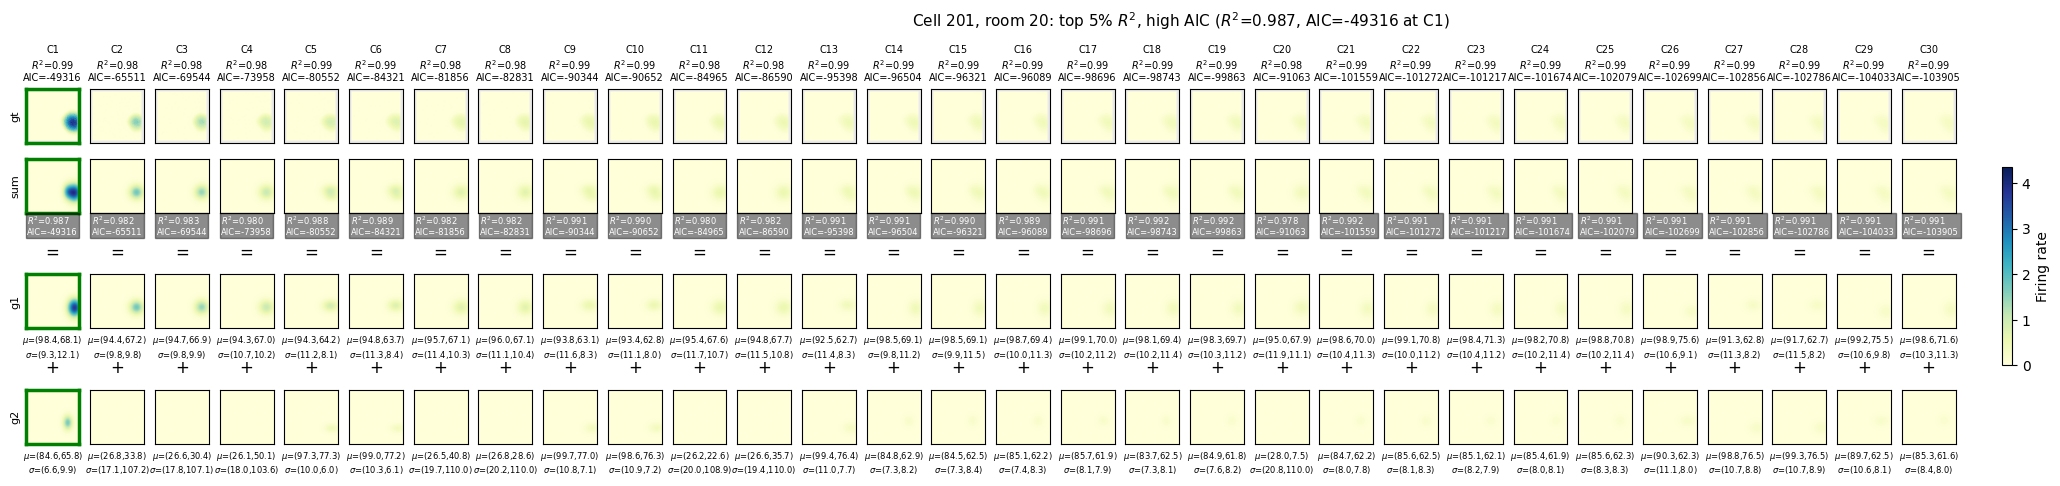

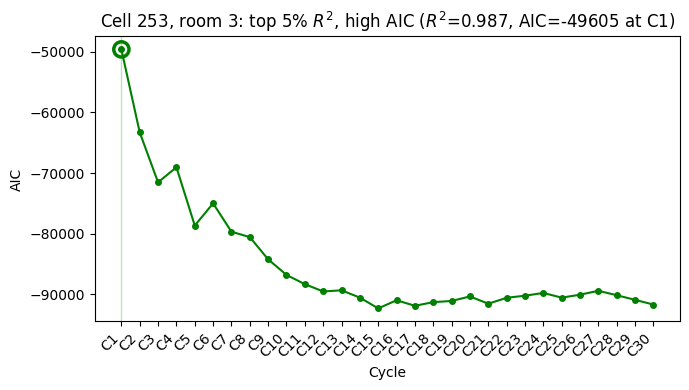

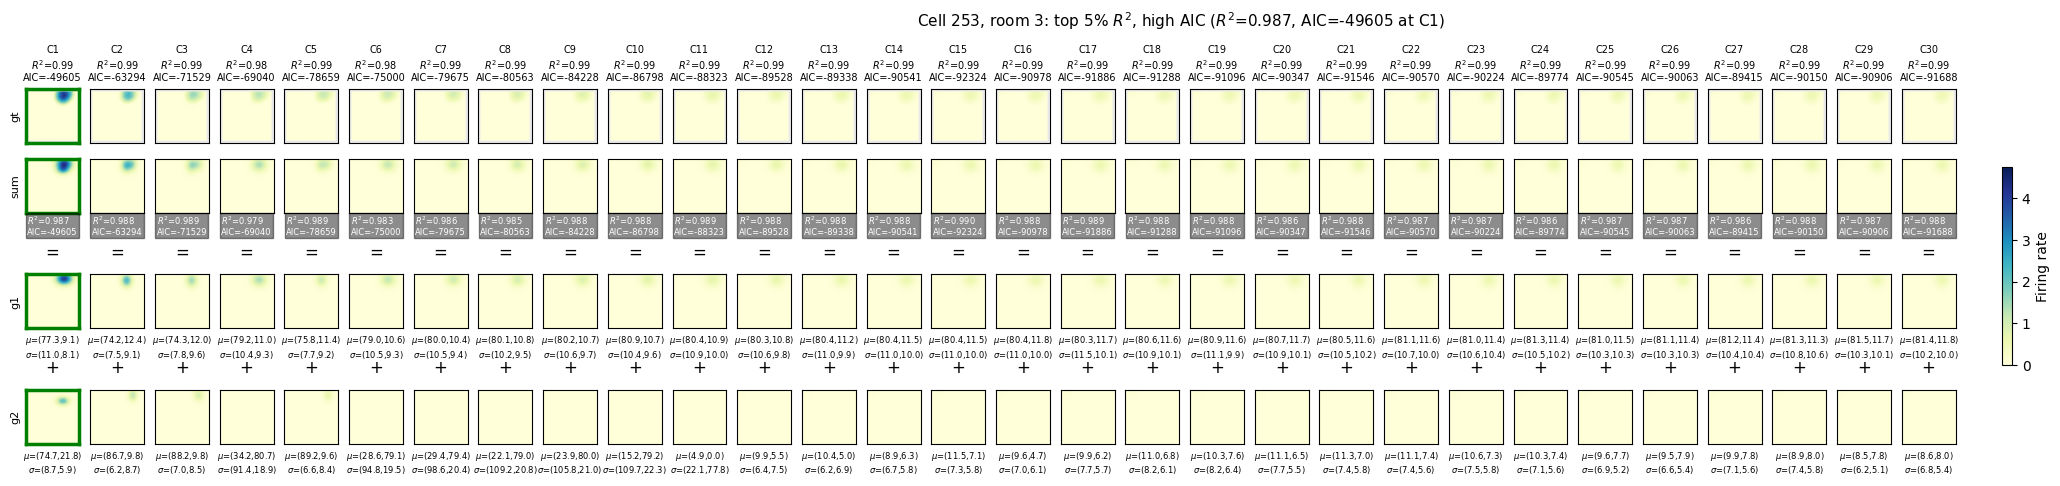

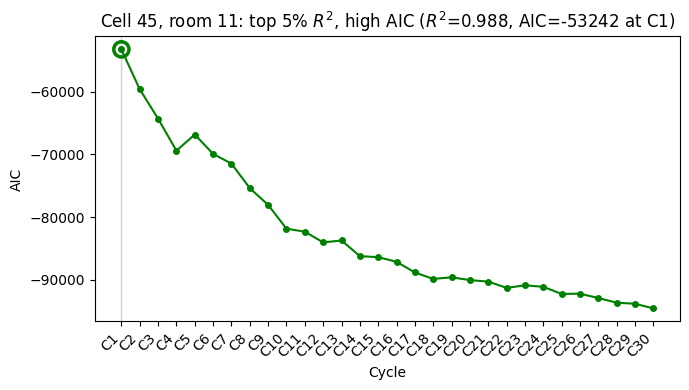

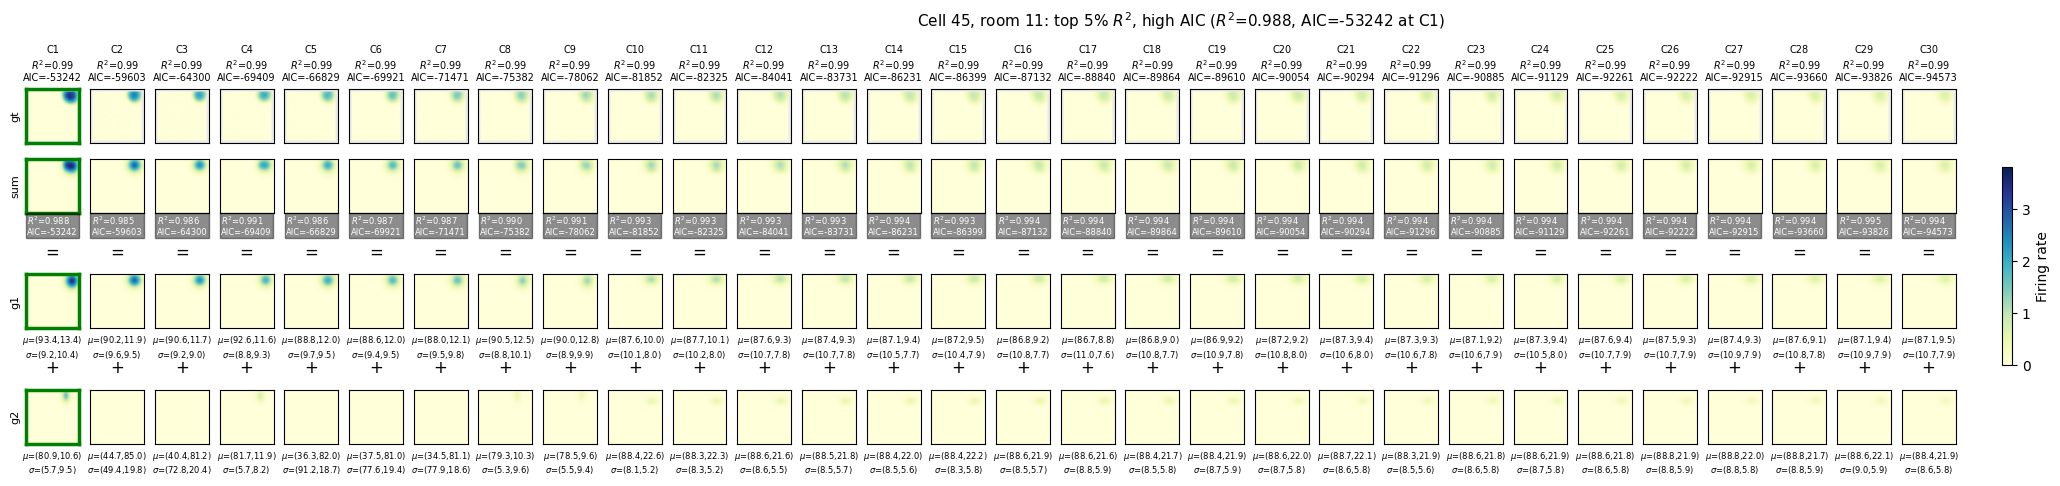

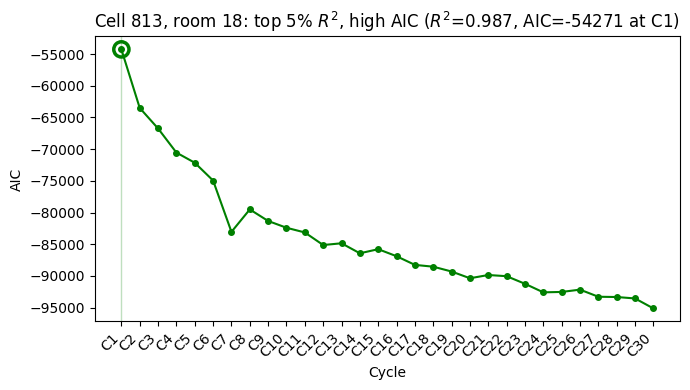

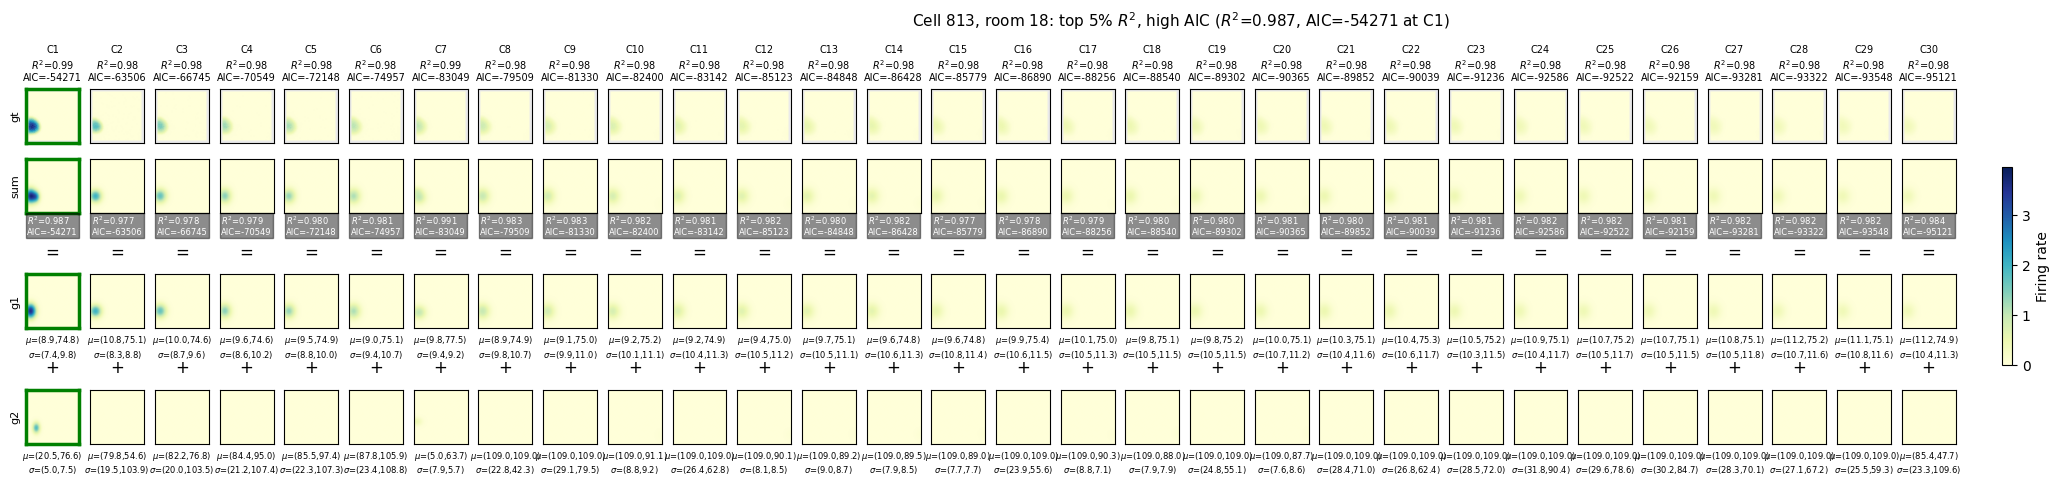

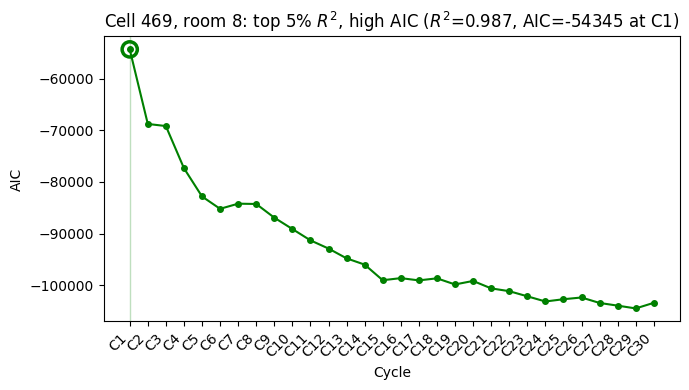

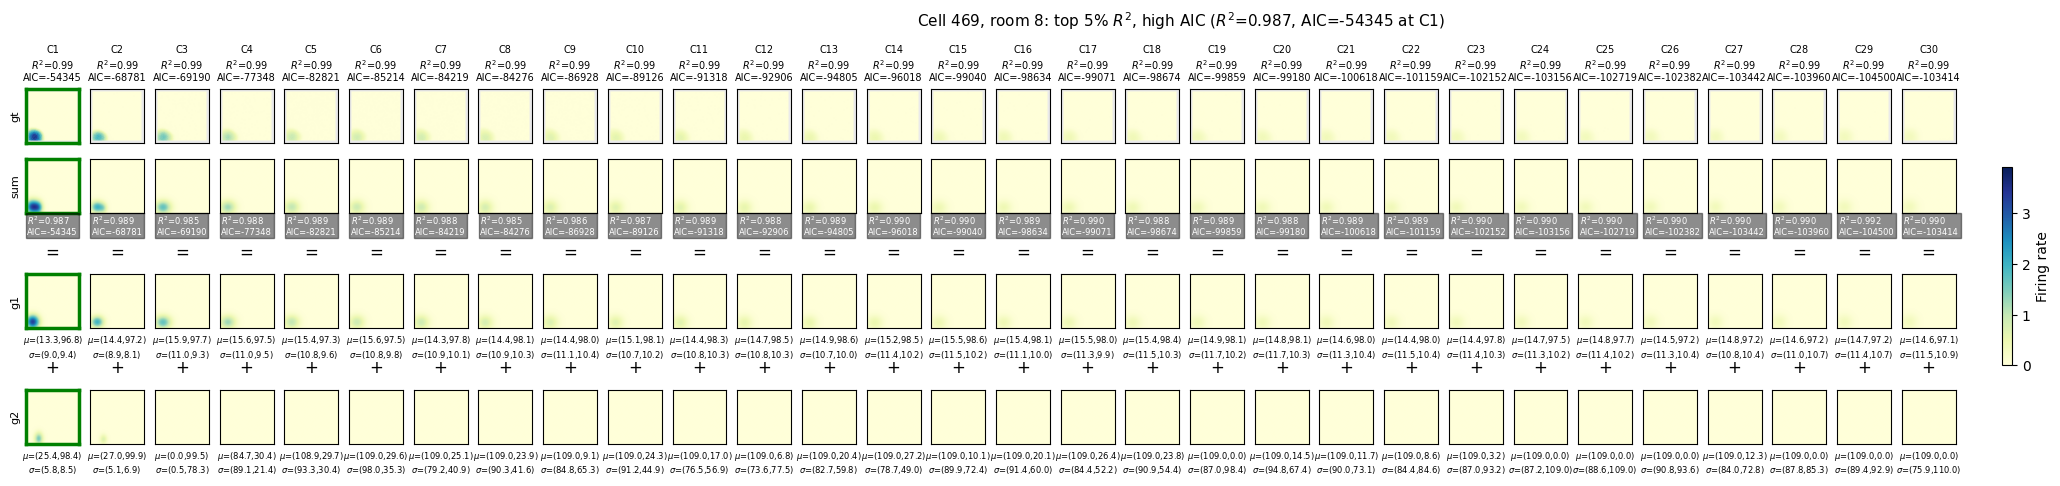

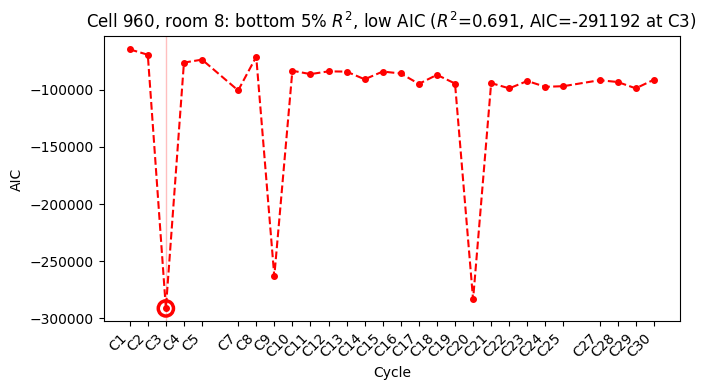

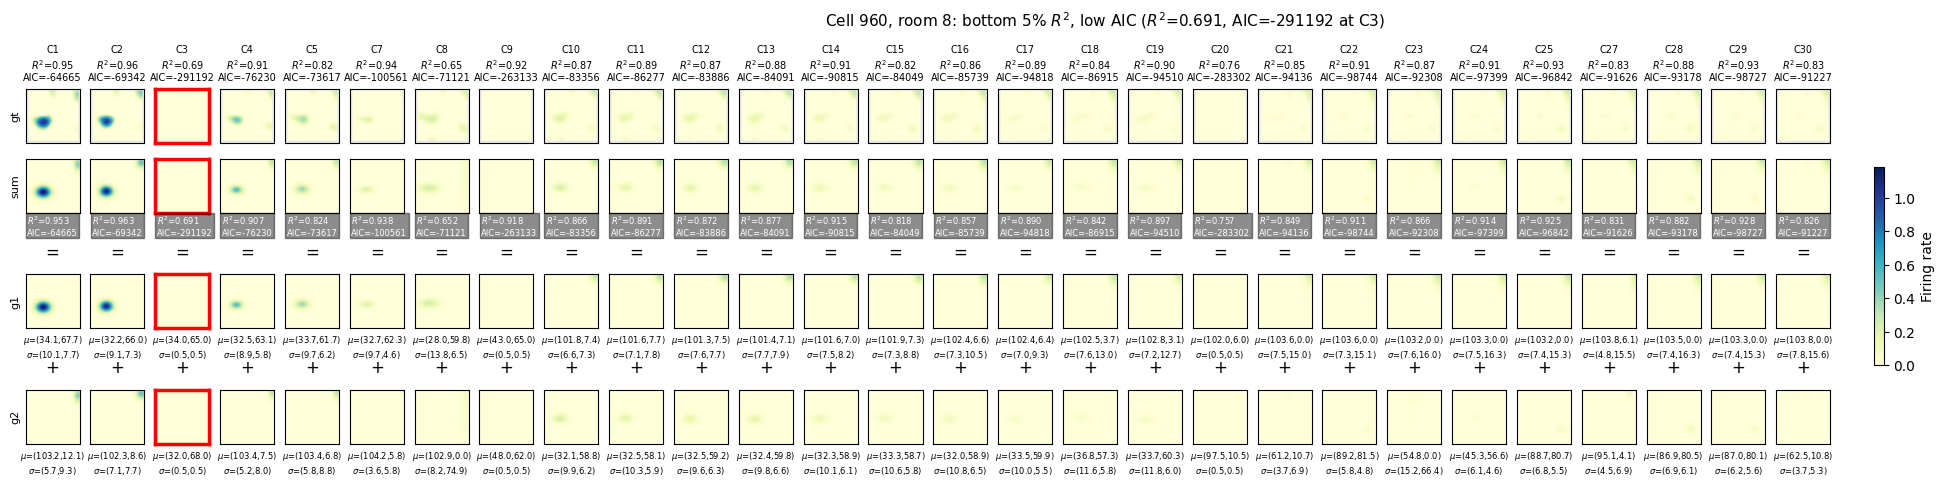

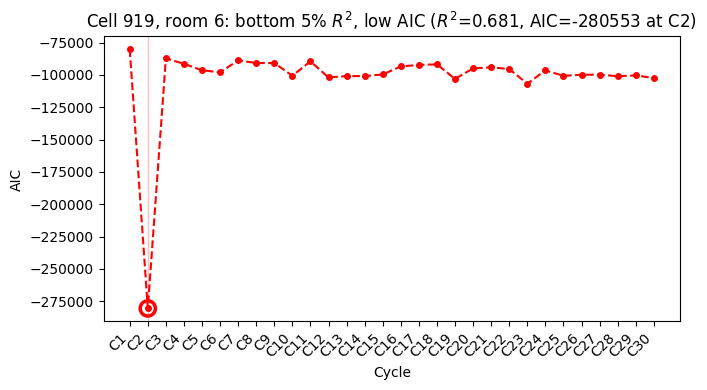

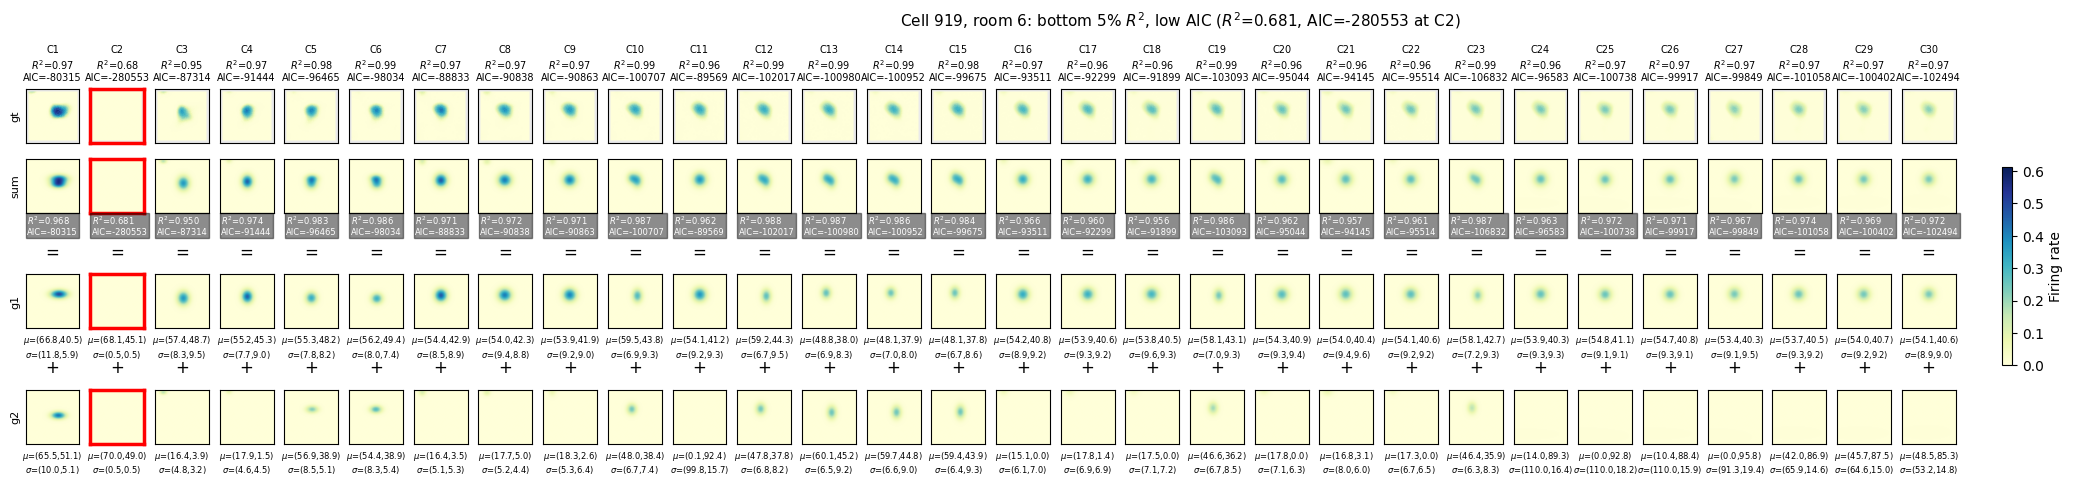

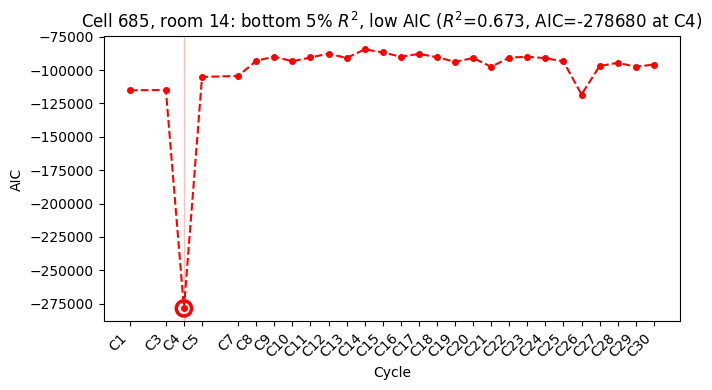

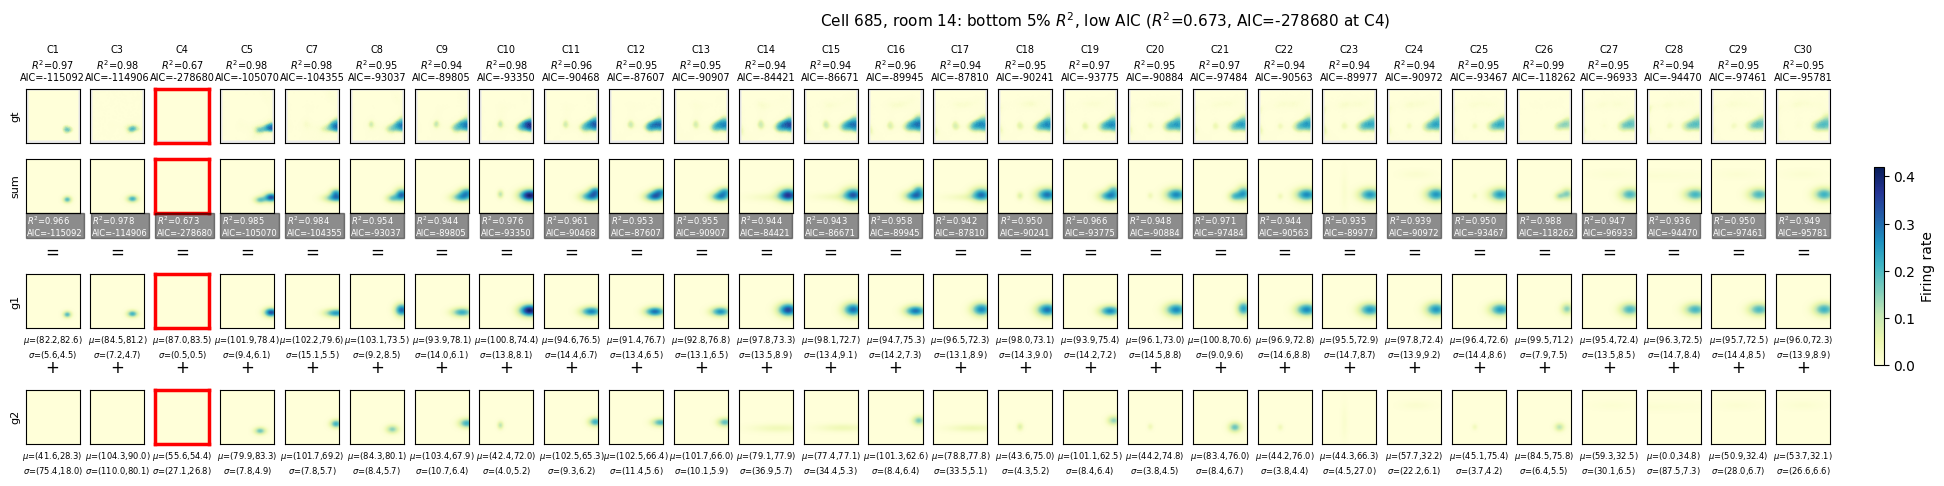

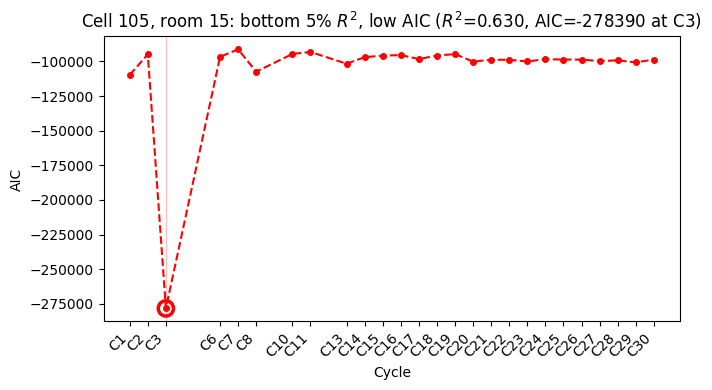

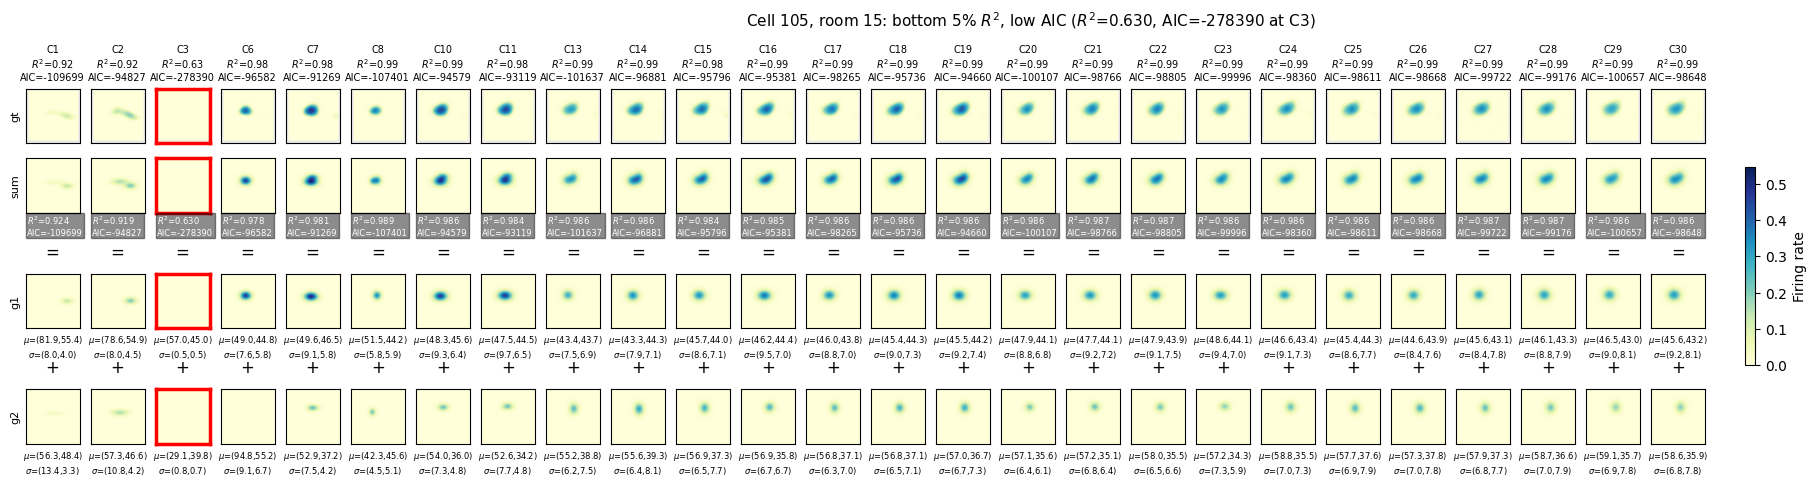

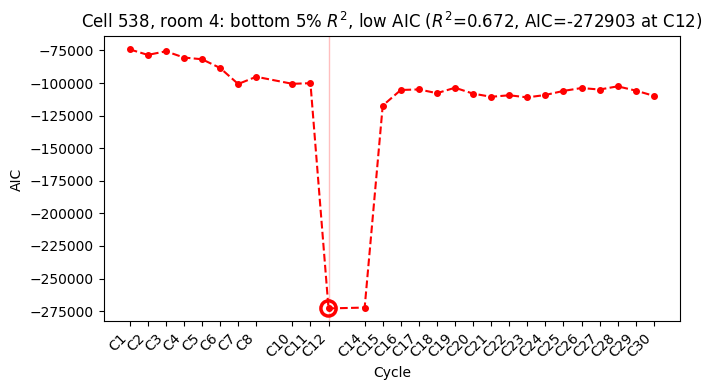

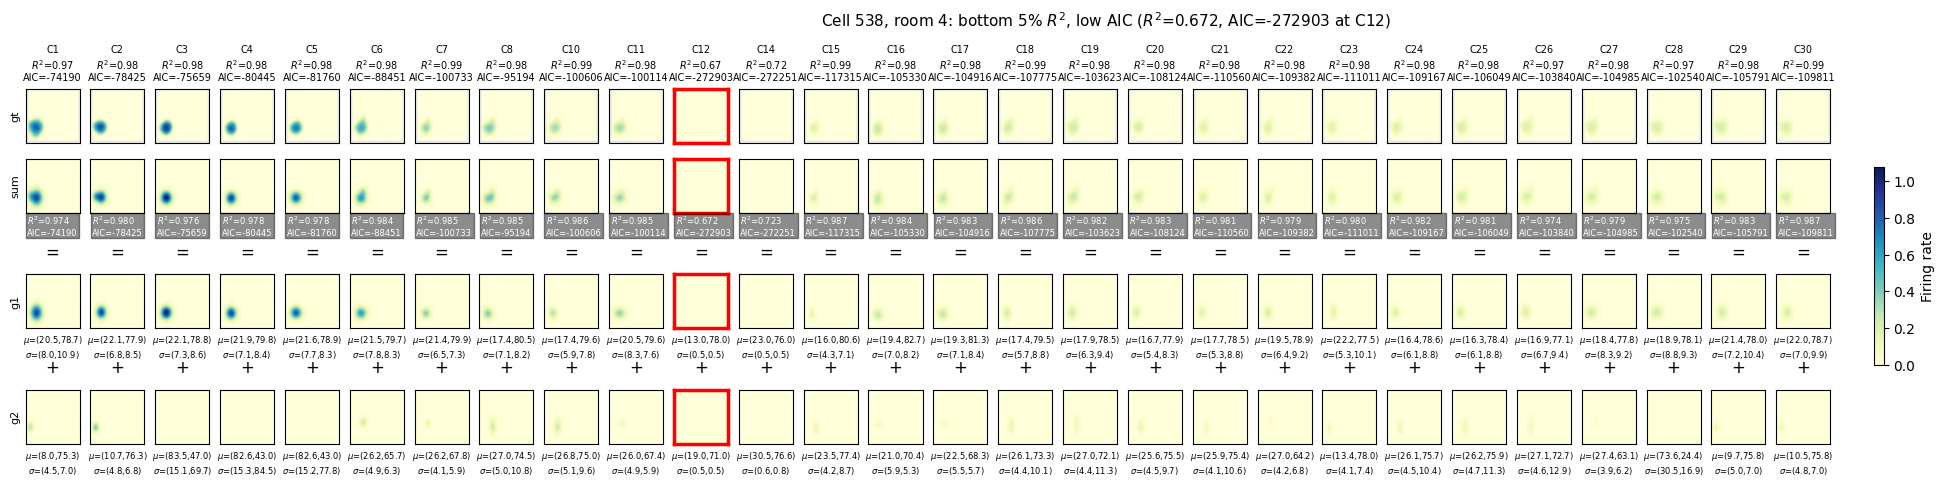

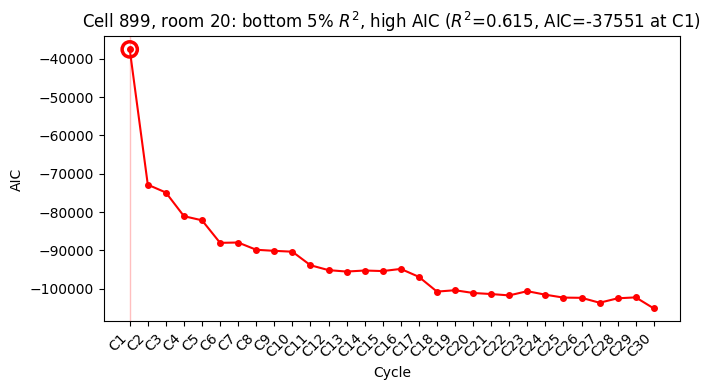

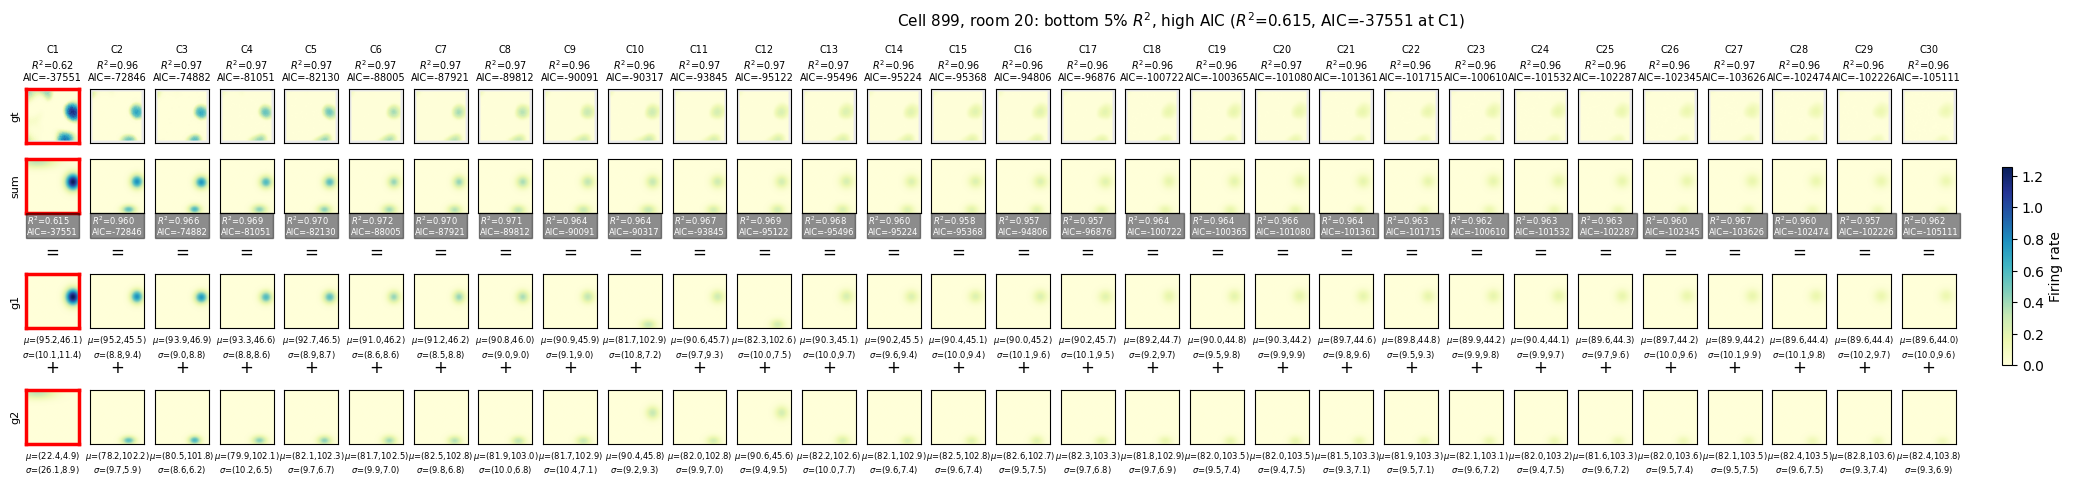

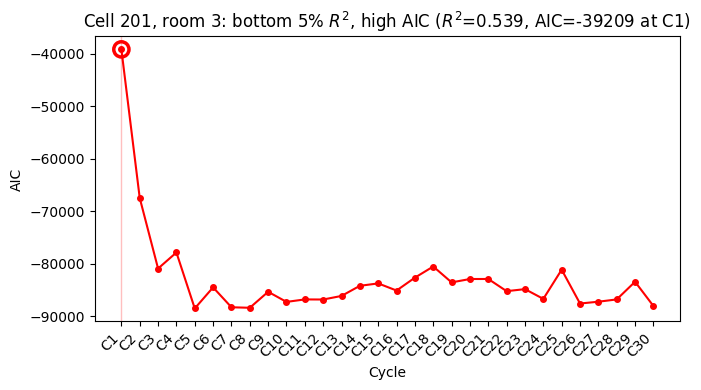

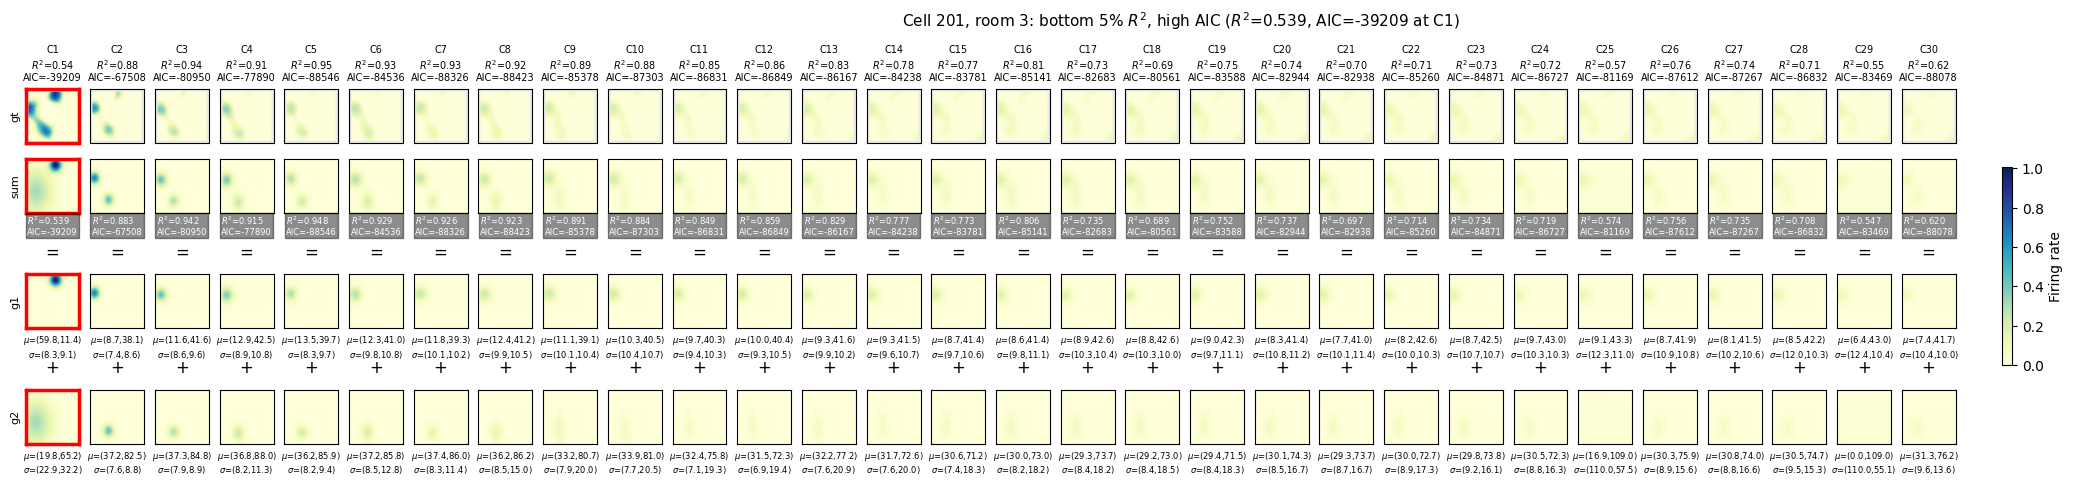

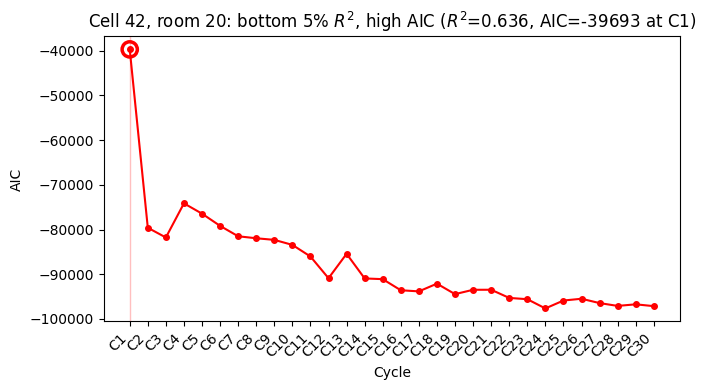

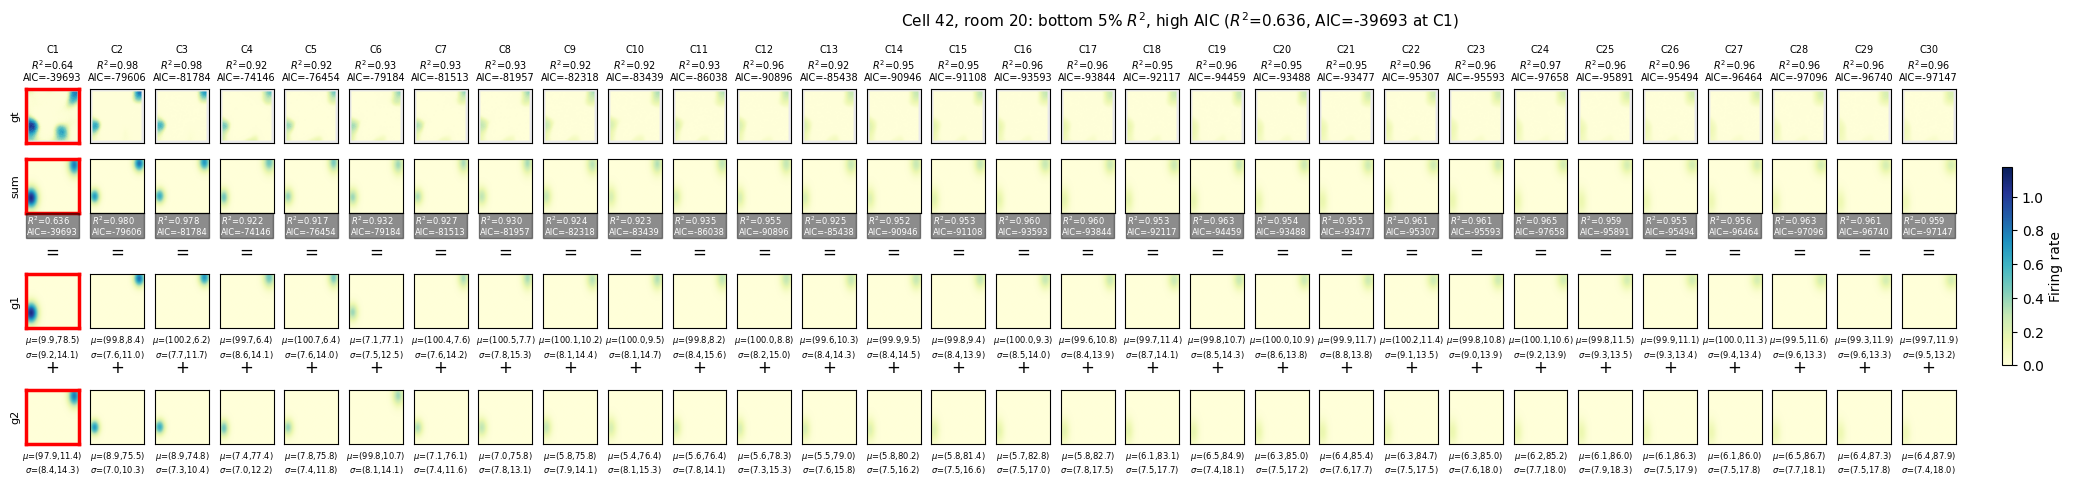

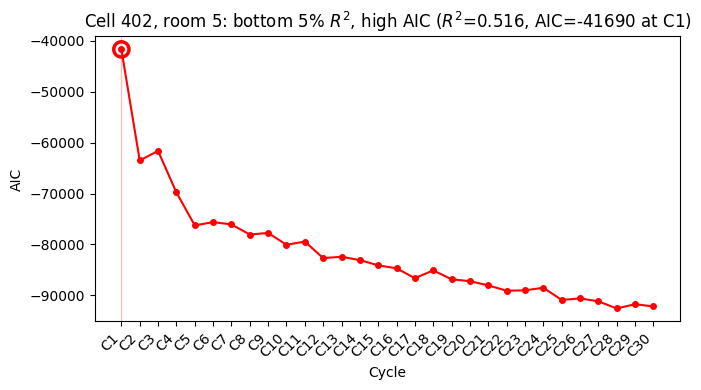

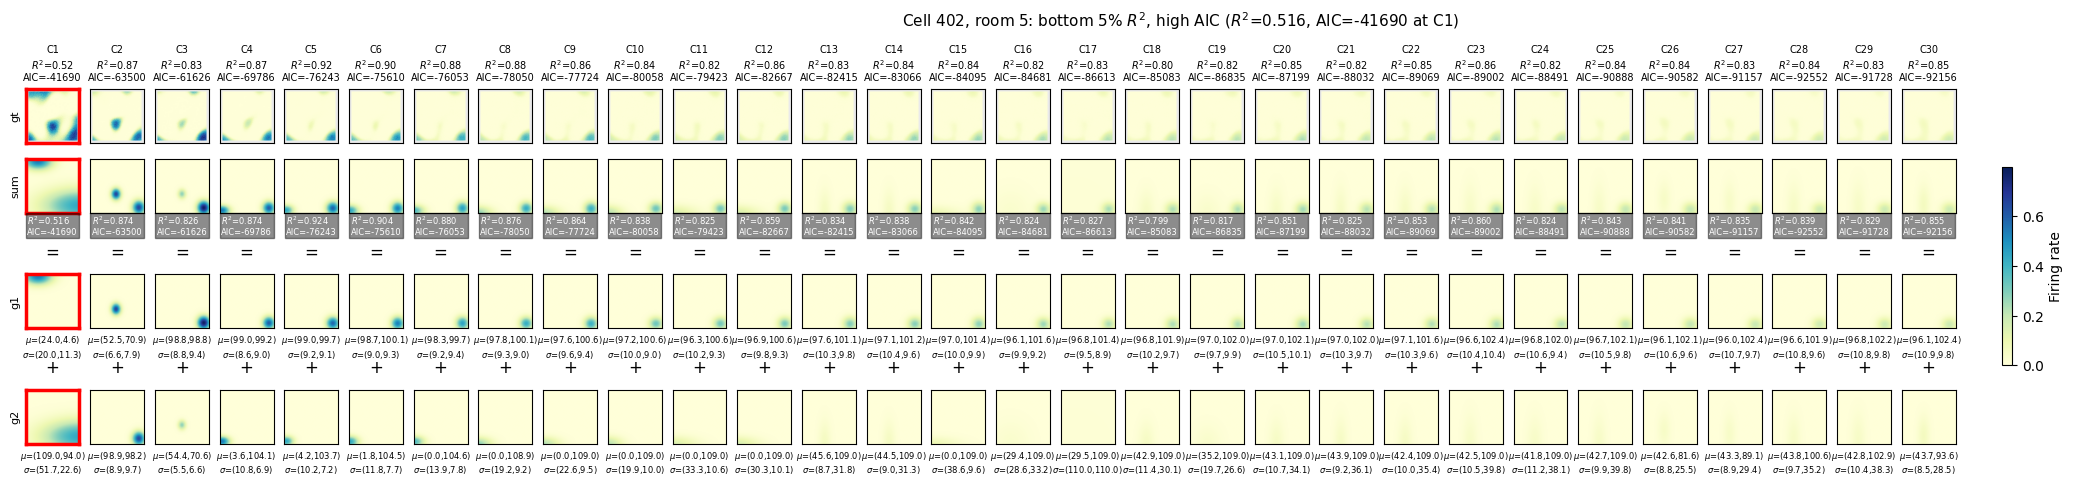

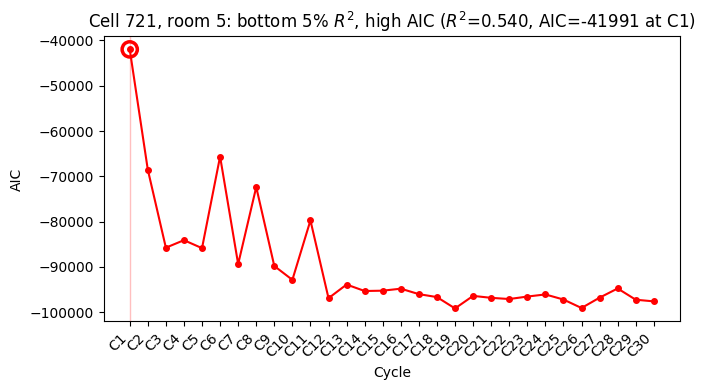

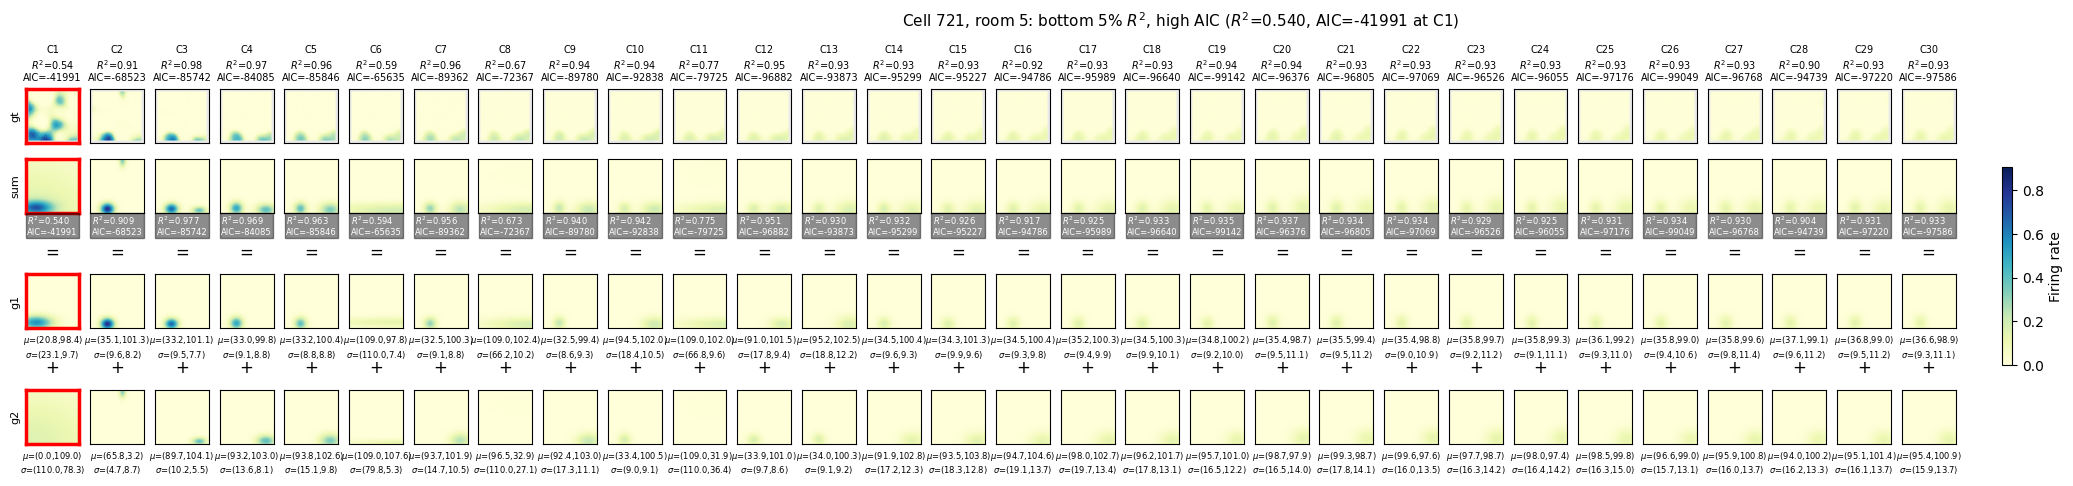

Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/cycles/plots/outliers/outlier_r2top_aiclow_cell247_room20_visit129_gaussian.pdf
Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/cycles/plots/outliers/outlier_r2top_aiclow_cell598_room9_visit570_gaussian.pdf
Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/cycles/plots/outliers/outlier_r2top_aiclow_cell81_room14_visit543_gaussian.pdf
Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/cycles/plots/outliers/outlier_r2top_aiclow_cell430_room12_visit583_gaussian.pdf
Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/cycles/plots/outliers/outlier_r2top_aiclow_cell425_room11_visit491_gaussian.pdf
Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/cycles/plots/outliers/outlier_r2top_aichigh_cell201_room20_visit1_gaussian.pdf
Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/cycles/plots/outliers/outl

In [11]:
N_OUTLIERS_PER_GROUP = 5
R2_POOL_FRACTION = 0.05
OUTLIER_PLOTS_DIR = PLOTS_DIR / "outliers"
SAVE_OUTLIER_PLOTS = True
OUTLIER_IM_WIDTH = 1.0

with np.load(GAUSSIANS_RESULTS_PATH) as meta:
    n_gaussians = int(meta["n_gaussians"])

outlier_points = select_aic_r2_outlier_points(
    df_aic_r2_correlation_filtered,
    n_per_group=N_OUTLIERS_PER_GROUP,
    r2_threshold=R2_THRESHOLD,
    r2_pool_fraction=R2_POOL_FRACTION,
)
outlier_summary = outlier_points_summary_df(outlier_points)
print(
    f"Selected {len(outlier_points)} outlier points "
    f"(target {4 * N_OUTLIERS_PER_GROUP}; "
    f"top/bottom {R2_POOL_FRACTION:.0%} $R^2$ pool, AIC extremes)"
)
display(outlier_summary)

metric_figs, gaussian_figs, initial_raw_gt_data = plot_all_outlier_analysis(
    df_aic_r2_correlation_filtered,
    TRUNCATED_FILE_PATHS,
    outlier_points,
    ratemaps_by_visit=initial_raw_gt_data,
    n_gaussians=n_gaussians,
    im_width=OUTLIER_IM_WIDTH,
)

OUTLIER_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

for point, fig in metric_figs:
    stem = (
        f"outlier_r2{point.r2_band}_aic{point.aic_extremum}_cell{point.cell_idx}"
        f"_room{point.room_id}_visit{point.visit_idx}_metric"
    )
    if SAVE_OUTLIER_PLOTS:
        save_figure(fig, OUTLIER_PLOTS_DIR / f"{stem}.pdf", close=False)
    plt.show()
    plt.close(fig)

for point, fig in gaussian_figs:
    stem = (
        f"outlier_r2{point.r2_band}_aic{point.aic_extremum}_cell{point.cell_idx}"
        f"_room{point.room_id}_visit{point.visit_idx}_gaussian"
    )
    if SAVE_OUTLIER_PLOTS:
        save_figure(fig, OUTLIER_PLOTS_DIR / f"{stem}.pdf", close=False)
    plt.show()
    plt.close(fig)
    if SAVE_OUTLIER_PLOTS:
        print(f"Saved {OUTLIER_PLOTS_DIR / stem}.pdf")
